# Flood Likelihood Prediction — North East & Yorkshire
### Clean ML Pipeline | Top-5 Towns | 4 Models | SHAP

**Dataset 1:** `open_flood_north_east_and_yorkshire.csv`  
**Dataset 2:** `open-meteo-54.09N0.87W41m (1).csv`  
**Target:** `prob_4band` — Very Low / Low / Medium / High  
**Models:** Logistic Regression · Random Forest · XGBoost · LightGBM

---
## Step 0 — Import Libraries

In [1]:
!pip install xgboost lightgbm

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import warnings, json
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (classification_report, confusion_matrix,
                             ConfusionMatrixDisplay, accuracy_score,
                             f1_score, precision_score, recall_score,
                             roc_curve, auc)
from sklearn.preprocessing import label_binarize
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

sns.set_theme(style='whitegrid', palette='Set2')
plt.rcParams.update({'figure.dpi': 120, 'font.size': 11})

RANDOM_STATE  = 42
TARGET_ORDER  = ['Low', 'Medium', 'High']
RISK_MAPPING  = {'Low': 0, 'Medium': 1, 'High': 2}
CLASS_NAMES   = ['Low', 'Medium', 'High']

print("✅ Libraries loaded")

Defaulting to user installation because normal site-packages is not writeable
✅ Libraries loaded


---
## Dataset 1 — Flood Data

### 1.1 Load & Basic Inspection

In [2]:
flood_df = pd.read_csv('open_flood_north_east_and_yorkshire.csv')
print(f"Shape: {flood_df.shape}")
flood_df.head()

Shape: (222365, 9)


,postcode,fid,prob_4band,suitability,pub_date,easting,northing,latitude,longitude
0,BB18 6JR,NaN,NaN,NaN,NaN,392300,447700,53.925375,-2.118742
1,BB18 6LB,NaN,NaN,NaN,NaN,392169,447032,53.919369,-2.120719
2,BB18 6LG,NaN,NaN,NaN,NaN,393104,446285,53.912668,-2.106466
3,BD1 1AA,1854757.0,Medium,County to Town,22/12/2013,416526,433330,53.796019,-1.750599
4,BD1 1AF,1456847.0,Medium,County to Town,01/08/2009,416546,433216,53.794994,-1.750301


In [3]:
flood_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 222365 entries, 0 to 222364
Data columns (total 9 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   postcode     222365 non-null  object 
 1   fid          21135 non-null   float64
 2   prob_4band   21135 non-null   object 
 3   suitability  21135 non-null   object 
 4   pub_date     21135 non-null   object 
 5   easting      222365 non-null  int64  
 6   northing     222365 non-null  int64  
 7   latitude     222365 non-null  float64
 8   longitude    222365 non-null  float64
dtypes: float64(3), int64(2), object(4)
memory usage: 15.3+ MB


In [4]:
flood_df.describe(include='all')

,postcode,fid,prob_4band,suitability,pub_date,easting,northing,latitude,longitude
count,222365,2.113500e+04,21135,21135,21135,222365.000000,222365.000000,222365.000000,222365.000000
unique,222365,NaN,4,4,10,NaN,NaN,NaN,NaN
top,BB18 6JR,NaN,Low,County to Town,22/12/2013,NaN,NaN,NaN,NaN
freq,1,NaN,12238,18368,9690,NaN,NaN,NaN,NaN
mean,NaN,1.153140e+06,NaN,NaN,NaN,440303.855341,469941.525667,54.122873,-1.386331
std,NaN,5.782535e+05,NaN,NaN,NaN,30067.285483,63572.194016,0.572159,0.456101
min,NaN,5.559200e+04,NaN,NaN,NaN,359573.000000,379032.000000,53.307407,-2.636650
25%,NaN,5.603130e+05,NaN,NaN,NaN,421930.000000,421455.000000,53.687599,-1.664876
50%,NaN,1.201396e+06,NaN,NaN,NaN,433348.000000,439873.000000,53.853150,-1.492979
75%,NaN,1.514474e+06,NaN,NaN,NaN,449603.000000,528426.000000,54.650045,-1.238468


### 1.2 Missing Values

In [5]:
mv  = flood_df.isnull().sum()
pct = (mv / len(flood_df) * 100).round(2)
missing = pd.DataFrame({'Missing Count': mv, 'Missing %': pct})
print(missing[missing['Missing Count'] > 0].to_string())

             Missing Count  Missing %
fid                 201230       90.5
prob_4band          201230       90.5
suitability         201230       90.5
pub_date            201230       90.5


### 1.3 Remove 'Very Low' Class

In [6]:
# 'Very Low' encodes to 0, making it indistinguishable from
# "no flood risk" in numeric models — removing it prevents training ambiguity.
print("prob_4band distribution BEFORE:")
print(flood_df['prob_4band'].value_counts(dropna=False).to_string())

before = len(flood_df)
flood_df = flood_df[flood_df['prob_4band'] != 'Very Low'].copy()
print(f"\nRemoved {before - len(flood_df):,} 'Very Low' rows")
print(f"\nprob_4band distribution AFTER:")
print(flood_df['prob_4band'].value_counts().to_string())

prob_4band distribution BEFORE:
prob_4band
NaN         201230
Low          12238
Medium        6107
High          1508
Very Low      1282

Removed 1,282 'Very Low' rows

prob_4band distribution AFTER:
prob_4band
Low       12238
Medium     6107
High       1508


### 1.4 Postcode → Town Mapping

Map each postcode district (e.g. `TS1`, `LS1`) to its town name.  
This gives a meaningful geographic grouping for the model.

In [7]:
DISTRICT_TO_TOWN = {
    'TS1':'Middlesbrough','TS2':'Middlesbrough','TS3':'Middlesbrough',
    'TS4':'Middlesbrough','TS5':'Middlesbrough','TS6':'Middlesbrough',
    'TS7':'Middlesbrough','TS8':'Middlesbrough','TS9':'Stokesley',
    'TS10':'Redcar','TS11':'Redcar','TS12':'Saltburn-by-the-Sea',
    'TS13':'Saltburn-by-the-Sea','TS14':'Guisborough','TS15':'Yarm',
    'TS16':'Stockton-on-Tees','TS17':'Stockton-on-Tees','TS18':'Stockton-on-Tees',
    'TS19':'Stockton-on-Tees','TS20':'Stockton-on-Tees','TS21':'Stockton-on-Tees',
    'TS22':'Billingham','TS23':'Billingham','TS24':'Hartlepool',
    'TS25':'Hartlepool','TS26':'Hartlepool','TS27':'Hartlepool',
    'TS28':'Wingate','TS29':'Trimdon',
    'NE1':'Newcastle upon Tyne','NE2':'Newcastle upon Tyne',
    'NE3':'Newcastle upon Tyne','NE4':'Newcastle upon Tyne',
    'NE5':'Newcastle upon Tyne','NE6':'Newcastle upon Tyne',
    'NE7':'Newcastle upon Tyne','NE8':'Gateshead','NE9':'Gateshead',
    'NE10':'Gateshead','NE11':'Gateshead','NE12':'Newcastle upon Tyne',
    'NE13':'Newcastle upon Tyne','NE15':'Newcastle upon Tyne',
    'NE16':'Whickham','NE17':'Gateshead','NE18':'Ponteland',
    'NE19':'Otterburn','NE20':'Ponteland','NE21':'Blaydon-on-Tyne',
    'NE22':'Bedlington','NE23':'Cramlington','NE24':'Blyth',
    'NE25':'Whitley Bay','NE26':'Whitley Bay','NE27':'Newcastle upon Tyne',
    'NE28':'Wallsend','NE29':'North Shields','NE30':'North Shields',
    'NE31':'Hebburn','NE32':'Jarrow','NE33':'South Shields',
    'NE34':'South Shields','NE35':'Boldon Colliery','NE36':'Boldon Colliery',
    'NE37':'Washington','NE38':'Washington','NE39':'Rowlands Gill',
    'NE40':'Ryton','NE41':'Wylam','NE42':'Prudhoe','NE43':'Stocksfield',
    'NE44':'Riding Mill','NE45':'Corbridge','NE46':'Hexham',
    'NE47':'Hexham','NE48':'Bellingham','NE49':'Haltwhistle',
    'NE61':'Morpeth','NE62':'Choppington','NE63':'Ashington',
    'NE64':'Newbiggin-by-the-Sea','NE65':'Amble','NE66':'Alnwick',
    'NE67':'Chathill','NE68':'Seahouses','NE69':'Bamburgh',
    'NE70':'Belford','NE71':'Wooler',
    'SR1':'Sunderland','SR2':'Sunderland','SR3':'Sunderland',
    'SR4':'Sunderland','SR5':'Sunderland','SR6':'Sunderland',
    'SR7':'Seaham','SR8':'Peterlee',
    'DH1':'Durham','DH2':'Chester-le-Street','DH3':'Chester-le-Street',
    'DH4':'Houghton le Spring','DH5':'Houghton le Spring','DH6':'Durham',
    'DH7':'Durham','DH8':'Consett','DH9':'Stanley',
    'DL1':'Darlington','DL2':'Darlington','DL3':'Darlington',
    'DL4':'Shildon','DL5':'Newton Aycliffe','DL6':'Northallerton',
    'DL7':'Northallerton','DL8':'Leyburn','DL9':'Catterick Garrison',
    'DL10':'Richmond','DL11':'Richmond','DL12':'Barnard Castle',
    'DL13':'Bishop Auckland','DL14':'Bishop Auckland','DL15':'Crook',
    'DL16':'Spennymoor','DL17':'Ferryhill',
    'YO1':'York','YO7':'Thirsk','YO8':'Selby','YO10':'York',
    'YO11':'Scarborough','YO12':'Scarborough','YO13':'Scarborough',
    'YO14':'Filey','YO15':'Bridlington','YO16':'Bridlington',
    'YO17':'Malton','YO18':'Pickering','YO19':'York',
    'YO21':'Whitby','YO22':'Whitby','YO23':'York',
    'YO24':'York','YO25':'Driffield','YO26':'York',
    'YO30':'York','YO31':'York','YO32':'York',
    'YO41':'York','YO42':'York','YO43':'Market Weighton',
    'YO51':'Boroughbridge','YO60':'York','YO61':'Easingwold','YO62':'Kirkbymoorside',
    'HG1':'Harrogate','HG2':'Harrogate','HG3':'Harrogate','HG4':'Ripon','HG5':'Knaresborough',
    'LS1':'Leeds','LS2':'Leeds','LS3':'Leeds','LS4':'Leeds','LS5':'Leeds',
    'LS6':'Leeds','LS7':'Leeds','LS8':'Leeds','LS9':'Leeds','LS10':'Leeds',
    'LS11':'Leeds','LS12':'Leeds','LS13':'Leeds','LS14':'Leeds','LS15':'Leeds',
    'LS16':'Leeds','LS17':'Leeds','LS18':'Horsforth','LS19':'Yeadon',
    'LS20':'Guiseley','LS21':'Otley','LS22':'Wetherby','LS23':'Boston Spa',
    'LS24':'Tadcaster','LS25':'Leeds','LS26':'Rothwell','LS27':'Morley',
    'LS28':'Pudsey','LS29':'Ilkley',
    'BD1':'Bradford','BD2':'Bradford','BD3':'Bradford','BD4':'Bradford',
    'BD5':'Bradford','BD6':'Bradford','BD7':'Bradford','BD8':'Bradford',
    'BD9':'Bradford','BD10':'Bradford','BD11':'Bradford','BD12':'Bradford',
    'BD13':'Bradford','BD14':'Bradford','BD15':'Bradford','BD16':'Bingley',
    'BD17':'Shipley','BD18':'Shipley','BD19':'Cleckheaton','BD20':'Keighley',
    'BD21':'Keighley','BD22':'Keighley','BD23':'Skipton','BD24':'Settle',
    'WF1':'Wakefield','WF2':'Wakefield','WF3':'Wakefield','WF4':'Wakefield',
    'WF5':'Ossett','WF6':'Normanton','WF7':'Pontefract','WF8':'Pontefract',
    'WF9':'South Elmsall','WF10':'Castleford','WF11':'Knottingley',
    'WF12':'Dewsbury','WF13':'Dewsbury','WF14':'Mirfield','WF15':'Liversedge',
    'WF16':'Heckmondwike','WF17':'Batley',
    'HD1':'Huddersfield','HD2':'Huddersfield','HD3':'Huddersfield',
    'HD4':'Huddersfield','HD5':'Huddersfield','HD6':'Brighouse',
    'HD7':'Holmfirth','HD8':'Huddersfield','HD9':'Holmfirth',
    'HX1':'Halifax','HX2':'Halifax','HX3':'Halifax','HX4':'Halifax',
    'HX5':'Elland','HX6':'Sowerby Bridge','HX7':'Hebden Bridge',
    'DN1':'Doncaster','DN2':'Doncaster','DN3':'Doncaster','DN4':'Doncaster',
    'DN5':'Doncaster','DN6':'Doncaster','DN7':'Doncaster','DN8':'Doncaster',
    'DN9':'Doncaster','DN10':'Doncaster','DN11':'Doncaster','DN12':'Doncaster',
    'DN14':'Goole','DN15':'Scunthorpe','DN16':'Scunthorpe','DN17':'Scunthorpe',
    'DN18':'Barton-upon-Humber','DN19':'Barrow-upon-Humber','DN20':'Brigg',
    'DN21':'Gainsborough','DN31':'Grimsby','DN32':'Grimsby','DN33':'Grimsby',
    'DN34':'Grimsby','DN35':'Cleethorpes','DN36':'Grimsby','DN37':'Grimsby',
    'DN38':'Brigg','DN39':'Ulceby','DN40':'Immingham','DN41':'Grimsby',
    'HU1':'Kingston upon Hull','HU2':'Kingston upon Hull','HU3':'Kingston upon Hull',
    'HU4':'Kingston upon Hull','HU5':'Kingston upon Hull','HU6':'Kingston upon Hull',
    'HU7':'Kingston upon Hull','HU8':'Kingston upon Hull','HU9':'Kingston upon Hull',
    'HU10':'Kirk Ella','HU11':'Kingston upon Hull','HU12':'Hedon',
    'HU13':'Hessle','HU14':'Brough','HU15':'Brough','HU16':'Cottingham',
    'HU17':'Beverley','HU18':'Hornsea','HU19':'Withernsea','HU20':'Brough',
    'S1':'Sheffield','S2':'Sheffield','S3':'Sheffield','S4':'Sheffield',
    'S5':'Sheffield','S6':'Sheffield','S7':'Sheffield','S8':'Sheffield',
    'S9':'Sheffield','S10':'Sheffield','S11':'Sheffield','S12':'Sheffield',
    'S13':'Sheffield','S14':'Sheffield','S17':'Sheffield','S20':'Sheffield',
    'S21':'Sheffield','S25':'Rotherham','S26':'Sheffield','S32':'Hope Valley',
    'S35':'Sheffield','S36':'Stocksbridge','S60':'Rotherham','S61':'Rotherham',
    'S62':'Rotherham','S63':'Rotherham','S64':'Mexborough','S65':'Rotherham',
    'S66':'Rotherham','S70':'Barnsley','S71':'Barnsley','S72':'Barnsley',
    'S73':'Barnsley','S74':'Barnsley','S75':'Barnsley','S80':'Worksop','S81':'Worksop',
    'LA2':'Lancaster','LA6':'Carnforth','LA10':'Sedbergh',
    'OL14':'Todmorden','OL15':'Littleborough',
    'CA8':'Brampton','CA9':'Alston',
    'BB18':'Barnoldswick','LN7':'Market Rasen','LN8':'Market Rasen',
}

flood_df['pc_district'] = flood_df['postcode'].str.extract(r'^([A-Z]{1,2}\d{1,2})')
flood_df['town']        = flood_df['pc_district'].map(DISTRICT_TO_TOWN).fillna('Unknown')
flood_df.drop(columns=['pc_district'], inplace=True)

print(f"Mapping coverage: {(flood_df['town'] != 'Unknown').mean()*100:.1f}%")
print(f"\nAll towns (count):")
print(flood_df['town'].value_counts().head(20).to_string())

Mapping coverage: 99.4%

All towns (count):
town
Leeds                  13801
Sheffield              11694
Bradford                9031
Doncaster               7815
Newcastle upon Tyne     7791
York                    7142
Kingston upon Hull      6305
Rotherham               5882
Barnsley                5680
Middlesbrough           4929
Sunderland              4702
Huddersfield            4550
Wakefield               4506
Stockton-on-Tees        4270
Halifax                 3856
Durham                  3516
Keighley                3284
Darlington              3234
Gateshead               2967
Harrogate               2830


### 1.5 Keep Top 5 Towns Only

In [8]:
# Identify top 5 towns by row count (excluding 'Unknown')
top5_towns = (flood_df[flood_df['town'] != 'Unknown']['town']
              .value_counts().head(5).index.tolist())
print(f"Top 5 towns: {top5_towns}")
print(f"\nRows before filter : {len(flood_df):,}")

flood_df = flood_df[flood_df['town'].isin(top5_towns)].copy()
print(f"Rows after filter  : {len(flood_df):,}")

# Confirm distribution
print(f"\nRow counts per town:")
print(flood_df['town'].value_counts().to_string())

Top 5 towns: ['Leeds', 'Sheffield', 'Bradford', 'Doncaster', 'Newcastle upon Tyne']

Rows before filter : 221,083
Rows after filter  : 50,132

Row counts per town:
town
Leeds                  13801
Sheffield              11694
Bradford                9031
Doncaster               7815
Newcastle upon Tyne     7791


### 1.6 Drop All Missing Values

In [9]:
print(f"Shape before dropna: {flood_df.shape}")
flood_df.dropna(inplace=True)
print(f"Shape after  dropna: {flood_df.shape}")
print(f"Missing values remaining: {flood_df.isnull().sum().sum()} ✅")

Shape before dropna: (50132, 10)
Shape after  dropna: (2988, 10)
Missing values remaining: 0 ✅


### 1.7 Drop Unnecessary Columns

In [10]:
flood_df.drop(columns=['postcode', 'fid', 'northing', 'easting'], inplace=True)
print(f"Remaining columns: {list(flood_df.columns)}")

Remaining columns: ['prob_4band', 'suitability', 'pub_date', 'latitude', 'longitude', 'town']


### 1.8 Remove Irrelevant Suitability Rows

In [11]:
# 'National to County' — too coarse for postcode-level prediction
# 'Street to Parcels of Land' — no flood risk assigned, adds noise
remove_vals = ['National to County', 'Street to Parcels of land']

print("Suitability distribution BEFORE:")
print(flood_df['suitability'].value_counts().to_string())

for val in remove_vals:
    before = len(flood_df)
    flood_df = flood_df[flood_df['suitability'] != val].copy()
    print(f"\nRemoved {before - len(flood_df):,} '{val}' rows")

print(f"\nSuitability distribution AFTER:")
print(flood_df['suitability'].value_counts().to_string())

Suitability distribution BEFORE:
suitability
County to Town               2980
National to County              7
Street to Parcels of land       1

Removed 7 'National to County' rows

Removed 1 'Street to Parcels of land' rows

Suitability distribution AFTER:
suitability
County to Town    2980


### 1.9 Rename & Parse Date → Set as Index

In [12]:
flood_df.rename(columns={'pub_date': 'date'}, inplace=True)
flood_df['date'] = pd.to_datetime(flood_df['date'], dayfirst=True, errors='coerce')

# Drop rows where date could not be parsed
before = len(flood_df)
flood_df.dropna(subset=['date'], inplace=True)
print(f"Dropped {before - len(flood_df)} rows with unparseable dates")

flood_df.set_index('date', inplace=True)
flood_df.sort_index(inplace=True)

print(f"\nFlood dataset ready:")
print(f"  Shape      : {flood_df.shape}")
print(f"  Date range : {flood_df.index.min().date()} → {flood_df.index.max().date()}")
flood_df.head()

Dropped 0 rows with unparseable dates

Flood dataset ready:
  Shape      : (2980, 5)
  Date range : 2009-08-01 → 2014-02-27


,prob_4band,suitability,latitude,longitude,town
date,,,,,
2009-08-01,High,County to Town,53.391767,-1.420362,Sheffield
2009-08-01,Low,County to Town,53.646724,-0.975746,Doncaster
2009-08-01,Low,County to Town,53.613343,-0.965625,Doncaster
2009-08-01,Low,County to Town,53.795469,-1.561736,Leeds
2009-08-01,Low,County to Town,53.795469,-1.561736,Leeds


---
## Dataset 2 — Weather Data

### 2.1 Load & Basic Inspection

In [13]:
weather_df = pd.read_csv('open-meteo-54.09N0.87W41m (1).csv', skiprows=3)
weather_df.columns = [
    'date', 'temp_mean', 'sunrise', 'sunset', 'temp_max', 'temp_min',
    'precipitation_sum', 'rain_sum', 'snowfall_sum', 'wind_speed_max',
    'wind_gusts_max', 'humidity_mean', 'soil_moisture_mean'
]
print(f"Shape: {weather_df.shape}")
weather_df.head()

Shape: (2922, 13)


,date,temp_mean,sunrise,sunset,temp_max,temp_min,precipitation_sum,rain_sum,snowfall_sum,wind_speed_max,wind_gusts_max,humidity_mean,soil_moisture_mean
0,2009-01-01,-0.6,2009-01-01T08:22,2009-01-01T15:51,1.7,-3.5,0.0,0.0,0.00,9.7,15.1,93,0.357
1,2009-01-02,1.5,2009-01-02T08:22,2009-01-02T15:52,3.9,-0.9,0.5,0.5,0.00,10.0,21.6,82,0.360
2,2009-01-03,-1.2,2009-01-03T08:22,2009-01-03T15:53,1.4,-2.8,0.0,0.0,0.00,11.2,19.4,84,0.357
3,2009-01-04,0.1,2009-01-04T08:21,2009-01-04T15:55,2.3,-1.7,0.5,0.5,0.00,15.8,28.8,86,0.355
4,2009-01-05,0.4,2009-01-05T08:21,2009-01-05T15:56,2.4,-1.4,0.9,0.6,0.21,17.0,31.3,79,0.365


In [14]:
weather_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2922 entries, 0 to 2921
Data columns (total 13 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   date                2922 non-null   object 
 1   temp_mean           2922 non-null   float64
 2   sunrise             2922 non-null   object 
 3   sunset              2922 non-null   object 
 4   temp_max            2922 non-null   float64
 5   temp_min            2922 non-null   float64
 6   precipitation_sum   2922 non-null   float64
 7   rain_sum            2922 non-null   float64
 8   snowfall_sum        2922 non-null   float64
 9   wind_speed_max      2922 non-null   float64
 10  wind_gusts_max      2922 non-null   float64
 11  humidity_mean       2922 non-null   int64  
 12  soil_moisture_mean  2922 non-null   float64
dtypes: float64(9), int64(1), object(3)
memory usage: 296.9+ KB


In [15]:
weather_df.describe()

,temp_mean,temp_max,temp_min,precipitation_sum,rain_sum,snowfall_sum,wind_speed_max,wind_gusts_max,humidity_mean,soil_moisture_mean
count,2922.000000,2922.000000,2922.000000,2922.000000,2922.000000,2922.000000,2922.000000,2922.000000,2922.000000,2922.000000
mean,9.194079,12.522279,5.697023,1.939151,1.870671,0.050667,21.848255,41.409993,81.443190,0.350356
std,5.235350,5.688460,5.049288,3.581342,3.527736,0.364765,8.433429,15.376325,7.870378,0.045535
min,-8.900000,-5.000000,-13.000000,0.000000,0.000000,0.000000,4.700000,9.700000,58.000000,0.167000
25%,5.300000,8.300000,2.000000,0.000000,0.000000,0.000000,15.500000,30.200000,76.000000,0.324000
50%,9.400000,12.600000,5.900000,0.300000,0.200000,0.000000,20.900000,39.200000,81.000000,0.361000
75%,13.400000,16.800000,9.700000,2.400000,2.200000,0.000000,26.900000,50.000000,87.000000,0.383000
max,22.200000,28.100000,17.900000,34.300000,34.300000,7.070000,56.700000,112.700000,100.000000,0.432000


### 2.2 Missing Values

In [16]:
mv_w = weather_df.isnull().sum()
print("Missing values:", "None ✅" if mv_w.sum()==0 else mv_w[mv_w>0].to_string())

Missing values: None ✅


### 2.3 Parse Date → Set as Index  
`sunrise` and `sunset` are time strings — not useful numeric features, dropping them.

In [17]:
weather_df['date'] = pd.to_datetime(weather_df['date'])
weather_df.drop(columns=['sunrise', 'sunset'], inplace=True)
weather_df.set_index('date', inplace=True)
weather_df.sort_index(inplace=True)

print(f"Weather dataset ready:")
print(f"  Shape      : {weather_df.shape}")
print(f"  Date range : {weather_df.index.min().date()} → {weather_df.index.max().date()}")
weather_df.head()

Weather dataset ready:
  Shape      : (2922, 10)
  Date range : 2009-01-01 → 2016-12-31


,temp_mean,temp_max,temp_min,precipitation_sum,rain_sum,snowfall_sum,wind_speed_max,wind_gusts_max,humidity_mean,soil_moisture_mean
date,,,,,,,,,,
2009-01-01,-0.6,1.7,-3.5,0.0,0.0,0.00,9.7,15.1,93,0.357
2009-01-02,1.5,3.9,-0.9,0.5,0.5,0.00,10.0,21.6,82,0.360
2009-01-03,-1.2,1.4,-2.8,0.0,0.0,0.00,11.2,19.4,84,0.357
2009-01-04,0.1,2.3,-1.7,0.5,0.5,0.00,15.8,28.8,86,0.355
2009-01-05,0.4,2.4,-1.4,0.9,0.6,0.21,17.0,31.3,79,0.365


---
## Step 3 — Combine Datasets on Date Index

In [18]:
# Inner join on the shared date index
# flood_df can have multiple rows per date; weather_df has one row per date
# The join correctly expands the daily weather row to all matching flood rows
df = flood_df.join(weather_df, how='inner')

print(f"Flood rows before join  : {len(flood_df):,}")
print(f"Combined rows after join: {len(df):,}")
print(f"Combined shape          : {df.shape}")
print(f"Date range              : {df.index.min().date()} → {df.index.max().date()}")
print(f"\nMissing values after join: {df.isnull().sum().sum()}")
df.head()

Flood rows before join  : 2,980
Combined rows after join: 2,980
Combined shape          : (2980, 15)
Date range              : 2009-08-01 → 2014-02-27

Missing values after join: 0


,prob_4band,suitability,latitude,longitude,town,temp_mean,temp_max,temp_min,precipitation_sum,rain_sum,snowfall_sum,wind_speed_max,wind_gusts_max,humidity_mean,soil_moisture_mean
date,,,,,,,,,,,,,,,
2009-08-01,High,County to Town,53.391767,-1.420362,Sheffield,15.0,17.2,12.8,4.5,4.5,0.0,19.4,39.2,84,0.369
2009-08-01,Low,County to Town,53.646724,-0.975746,Doncaster,15.0,17.2,12.8,4.5,4.5,0.0,19.4,39.2,84,0.369
2009-08-01,Low,County to Town,53.613343,-0.965625,Doncaster,15.0,17.2,12.8,4.5,4.5,0.0,19.4,39.2,84,0.369
2009-08-01,Low,County to Town,53.795469,-1.561736,Leeds,15.0,17.2,12.8,4.5,4.5,0.0,19.4,39.2,84,0.369
2009-08-01,Low,County to Town,53.795469,-1.561736,Leeds,15.0,17.2,12.8,4.5,4.5,0.0,19.4,39.2,84,0.369


In [19]:
print("Column overview:")
print(df.dtypes.to_string())
print(f"\nTarget distribution:")
print(df['prob_4band'].value_counts().reindex(TARGET_ORDER).to_string())

Column overview:
prob_4band             object
suitability            object
latitude              float64
longitude             float64
town                   object
temp_mean             float64
temp_max              float64
temp_min              float64
precipitation_sum     float64
rain_sum              float64
snowfall_sum          float64
wind_speed_max        float64
wind_gusts_max        float64
humidity_mean           int64
soil_moisture_mean    float64

Target distribution:
prob_4band
Low       1349
Medium    1506
High       125


---
## Step 4 — Exploratory Data Analysis (EDA)

### 4.1 Target Variable Distribution

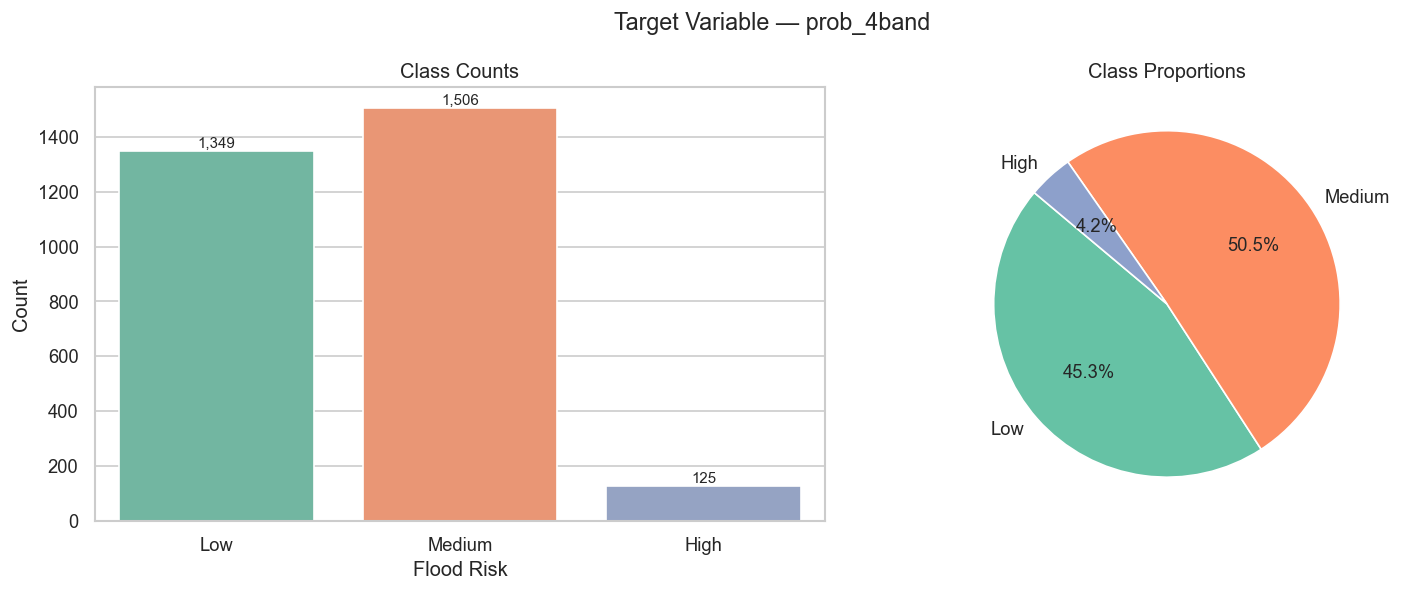

In [20]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
counts = df['prob_4band'].value_counts().reindex(TARGET_ORDER)

sns.barplot(x=counts.index, y=counts.values, palette='Set2',
            order=TARGET_ORDER, ax=axes[0])
for p in axes[0].patches:
    axes[0].annotate(f'{int(p.get_height()):,}',
        (p.get_x()+p.get_width()/2, p.get_height()),
        ha='center', va='bottom', fontsize=9)
axes[0].set_title('Class Counts', fontsize=12)
axes[0].set_xlabel('Flood Risk'); axes[0].set_ylabel('Count')

axes[1].pie(counts.values, labels=counts.index, autopct='%1.1f%%',
            colors=sns.color_palette('Set2', 4), startangle=140)
axes[1].set_title('Class Proportions', fontsize=12)
plt.suptitle('Target Variable — prob_4band', fontsize=14)
plt.tight_layout(); plt.savefig('eda_01_target.png', bbox_inches='tight'); plt.show()

### 4.2 Flood Risk by Town

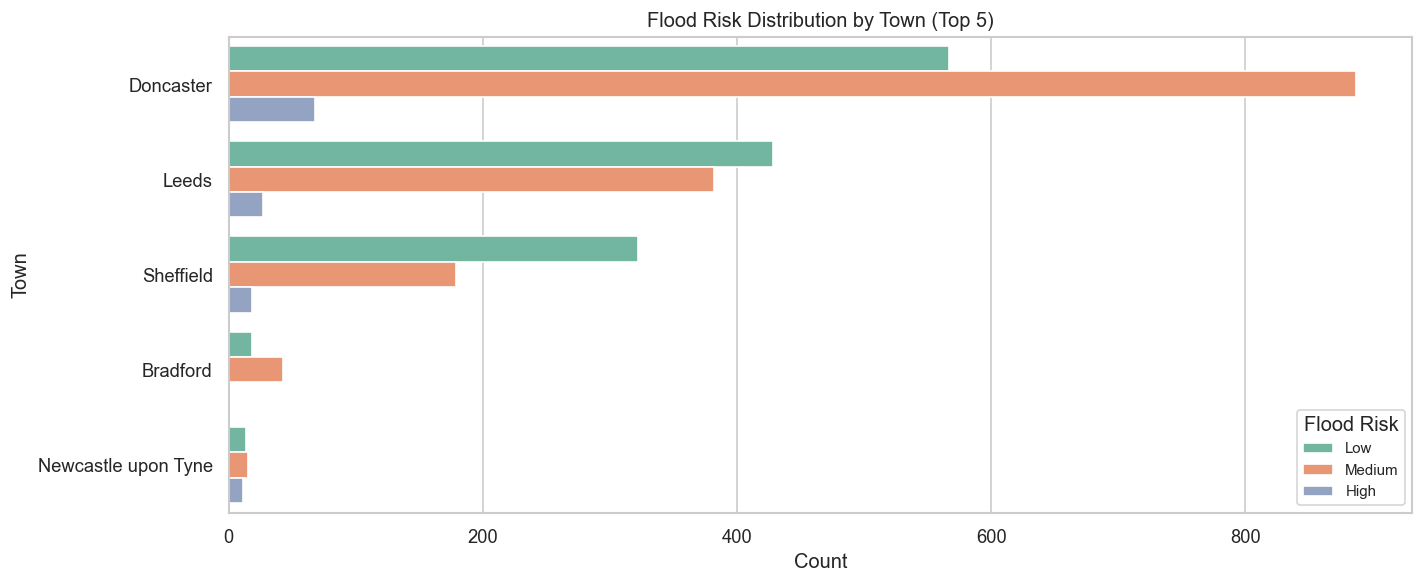

In [21]:
fig, ax = plt.subplots(figsize=(12, 5))
sns.countplot(data=df.reset_index(), y='town', hue='prob_4band',
              palette='Set2', hue_order=TARGET_ORDER,
              order=df['town'].value_counts().index, ax=ax)
ax.set_title('Flood Risk Distribution by Town (Top 5)', fontsize=12)
ax.set_xlabel('Count'); ax.set_ylabel('Town')
ax.legend(title='Flood Risk', fontsize=9)
plt.tight_layout(); plt.savefig('eda_02_town.png', bbox_inches='tight'); plt.show()

### 4.3 Flood Risk by Suitability

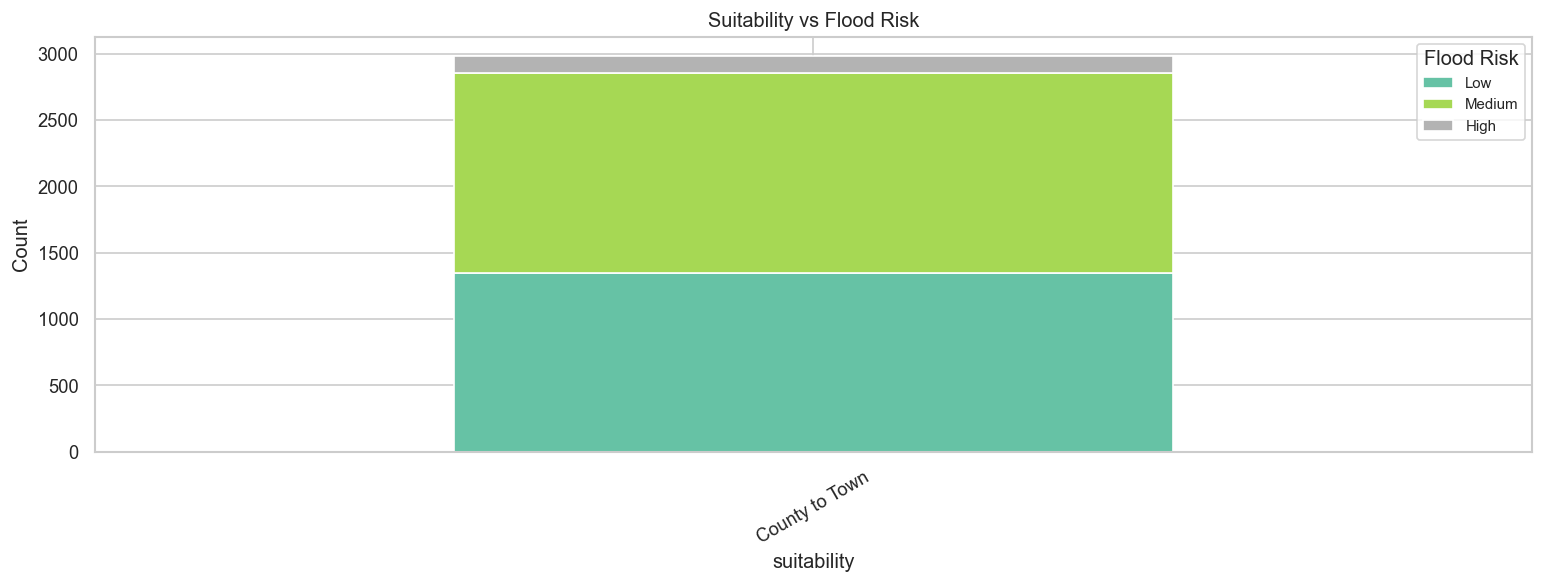

In [22]:
fig, ax = plt.subplots(figsize=(13, 5))
suit_ct = pd.crosstab(df['suitability'], df['prob_4band'])
suit_ct[[c for c in TARGET_ORDER if c in suit_ct.columns]].plot(
    kind='bar', stacked=True, colormap='Set2', ax=ax, rot=30)
ax.set_title('Suitability vs Flood Risk', fontsize=12)
ax.set_ylabel('Count'); ax.legend(title='Flood Risk', fontsize=9)
plt.tight_layout(); plt.savefig('eda_03_suitability.png', bbox_inches='tight'); plt.show()

### 4.4 Numerical Feature Distributions by Flood Risk (KDE)

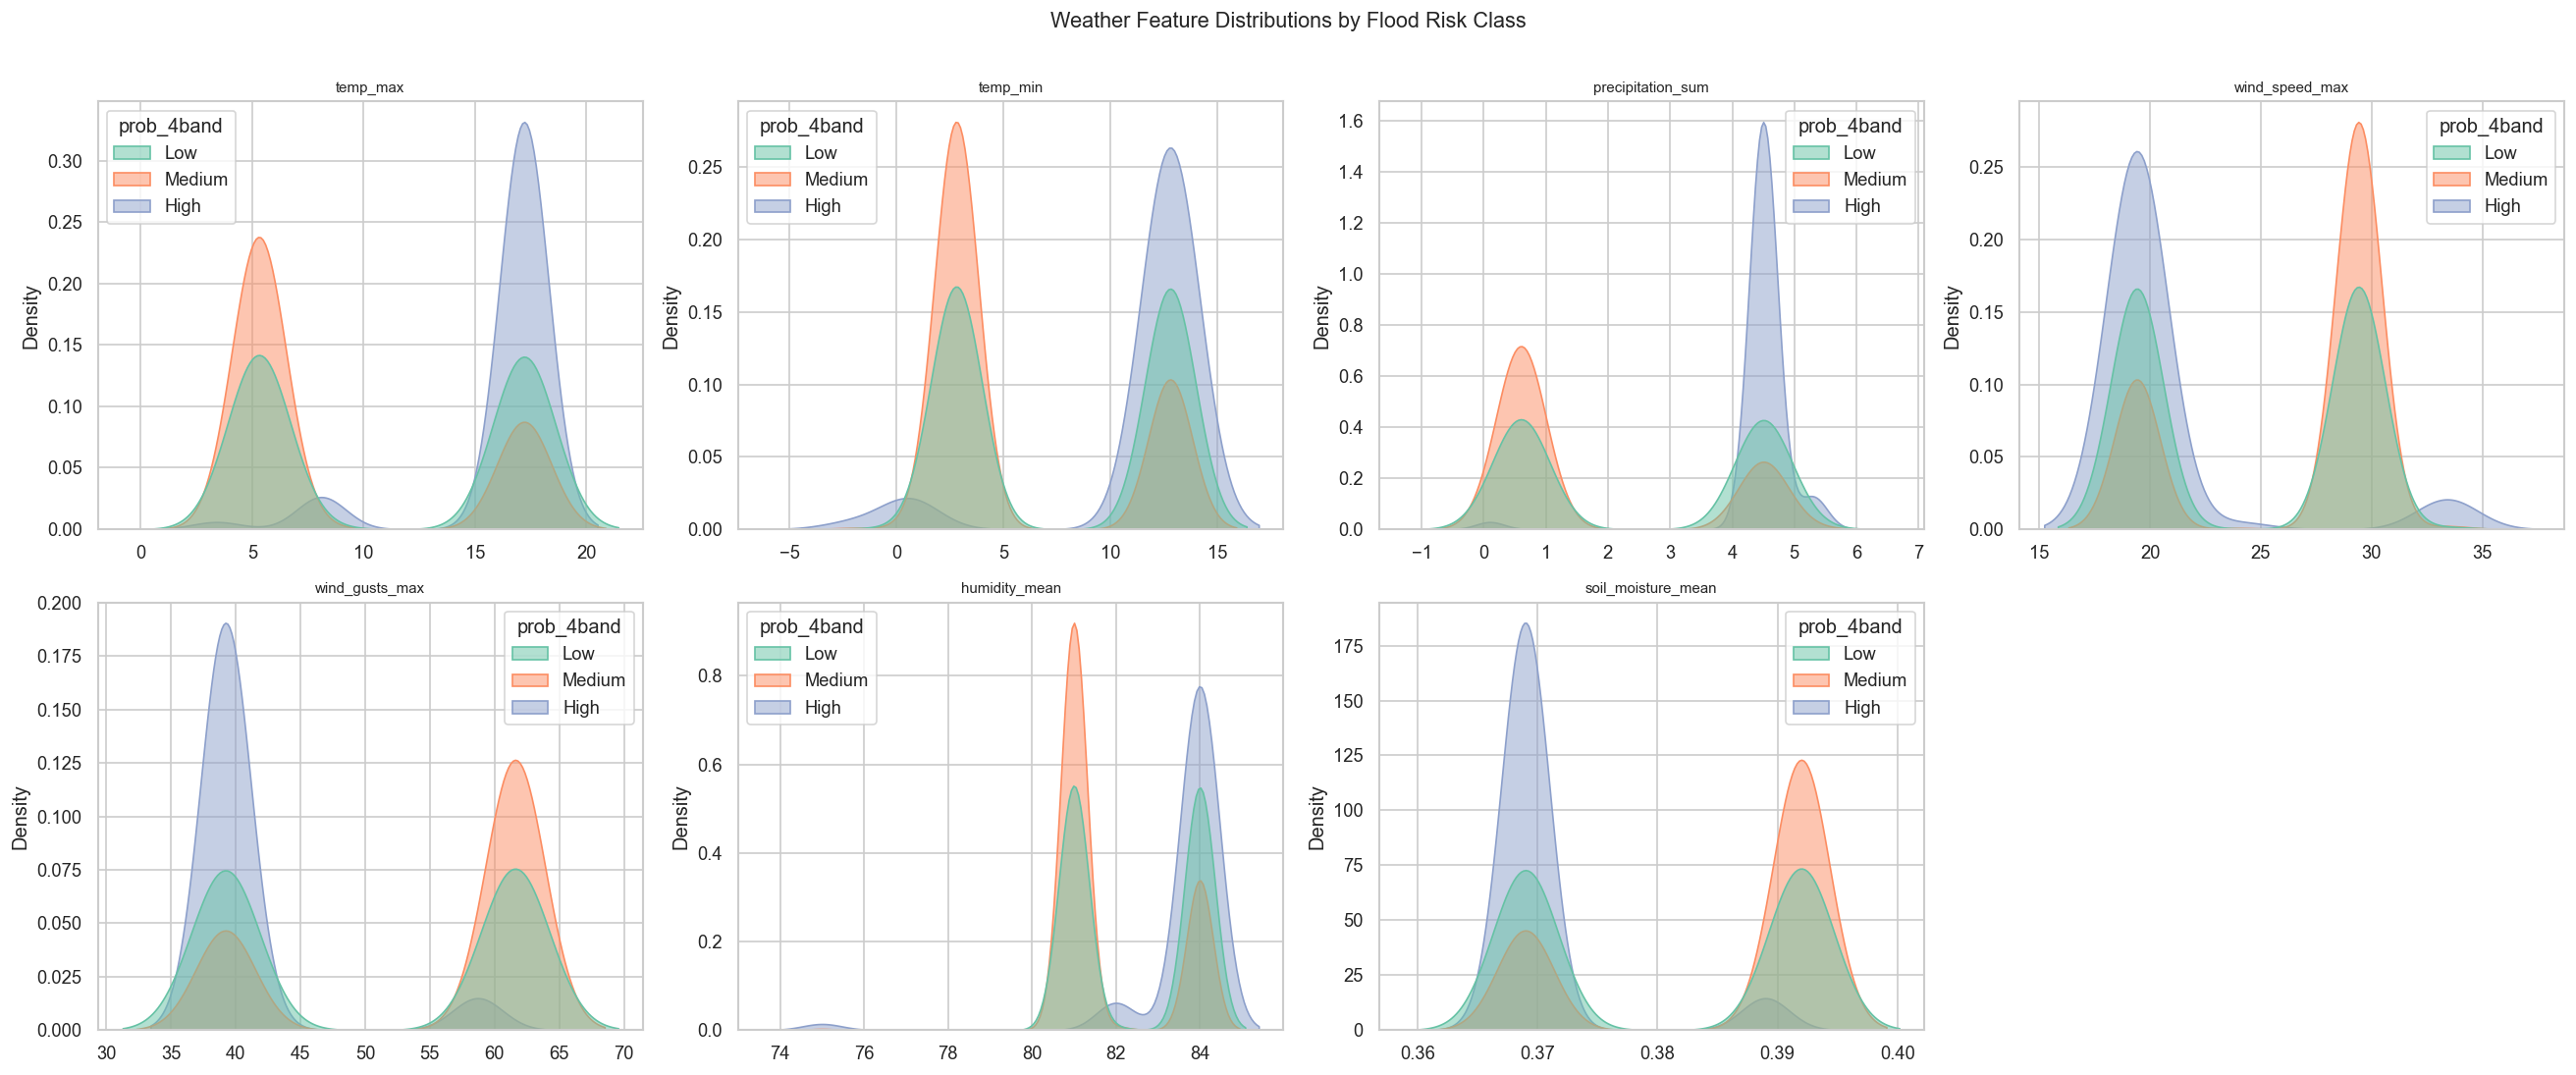

In [23]:
num_weather = ['temp_max', 'temp_min', 'precipitation_sum',
               'wind_speed_max', 'wind_gusts_max', 'humidity_mean', 'soil_moisture_mean']

fig, axes = plt.subplots(2, 4, figsize=(22, 9)); axes = axes.flatten()
for i, col in enumerate(num_weather):
    sns.kdeplot(data=df.reset_index(), x=col, hue='prob_4band',
                hue_order=TARGET_ORDER, fill=True, common_norm=False,
                palette='Set2', alpha=0.5, ax=axes[i])
    axes[i].set_title(f'{col}', fontsize=9)
    axes[i].set_xlabel('')
axes[-1].set_visible(False)
plt.suptitle('Weather Feature Distributions by Flood Risk Class', fontsize=13, y=1.01)
plt.tight_layout(); plt.savefig('eda_04_kde.png', bbox_inches='tight'); plt.show()

### 4.5 Weather Trends Over Time

### 4.6 Correlation Heatmap

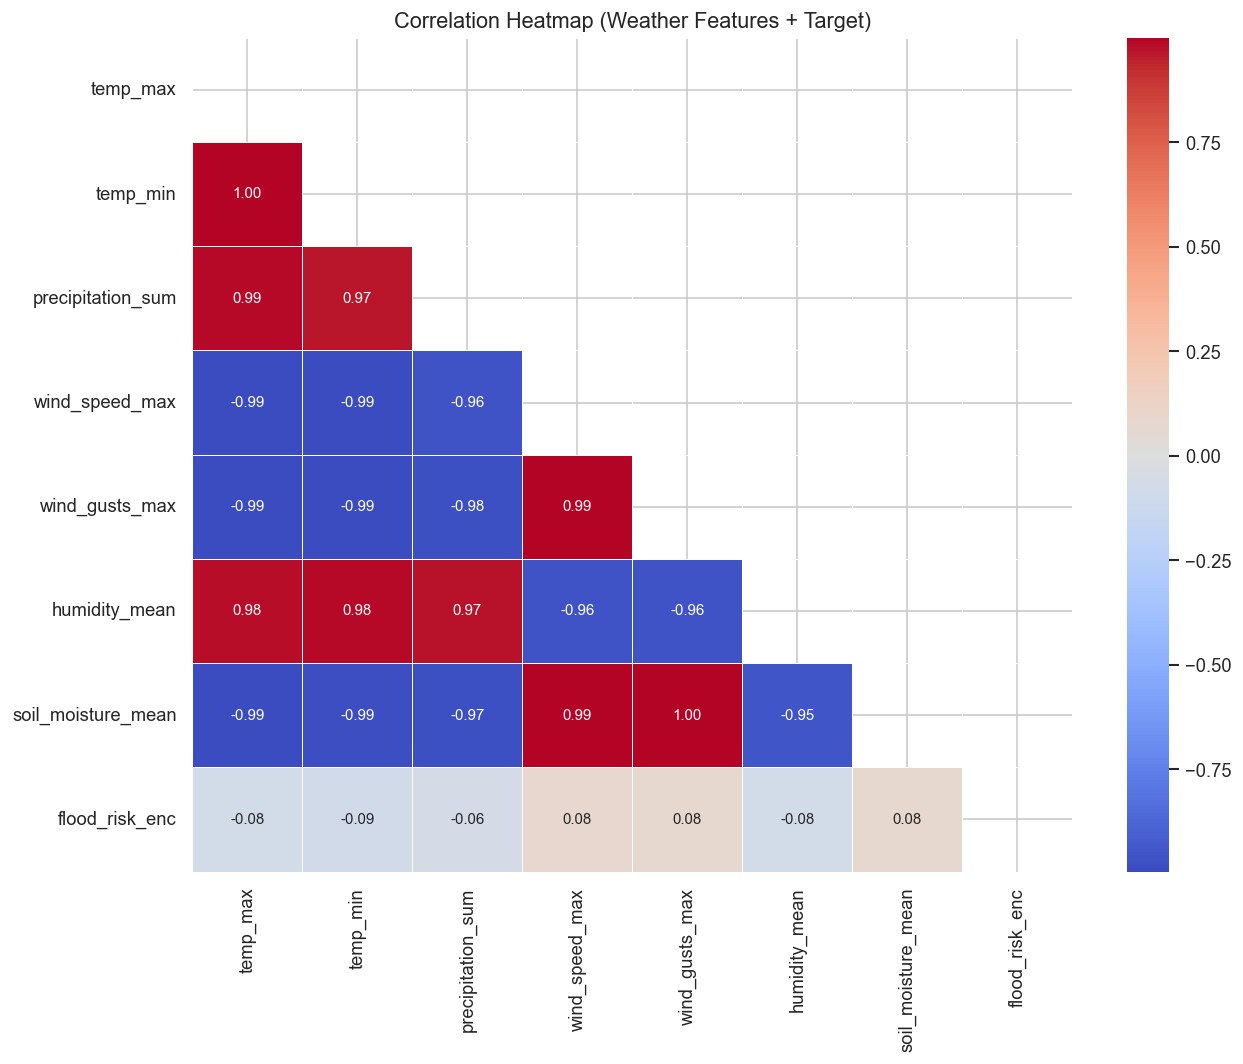

In [24]:
df_corr = df[num_weather].copy()
df_corr['flood_risk_enc'] = df['prob_4band'].map(RISK_MAPPING)
fig, ax = plt.subplots(figsize=(11, 9))
mask = np.triu(np.ones_like(df_corr.corr(), dtype=bool))
sns.heatmap(df_corr.corr(), mask=mask, annot=True, fmt='.2f',
            cmap='coolwarm', center=0, ax=ax, linewidths=0.5,
            annot_kws={'size': 9})
ax.set_title('Correlation Heatmap (Weather Features + Target)', fontsize=13)
plt.tight_layout(); plt.savefig('eda_06_correlation.png', bbox_inches='tight'); plt.show()

---
## Step 5 — Outlier Detection & IQR Fix

### 5.1 Box Plots — Before Capping

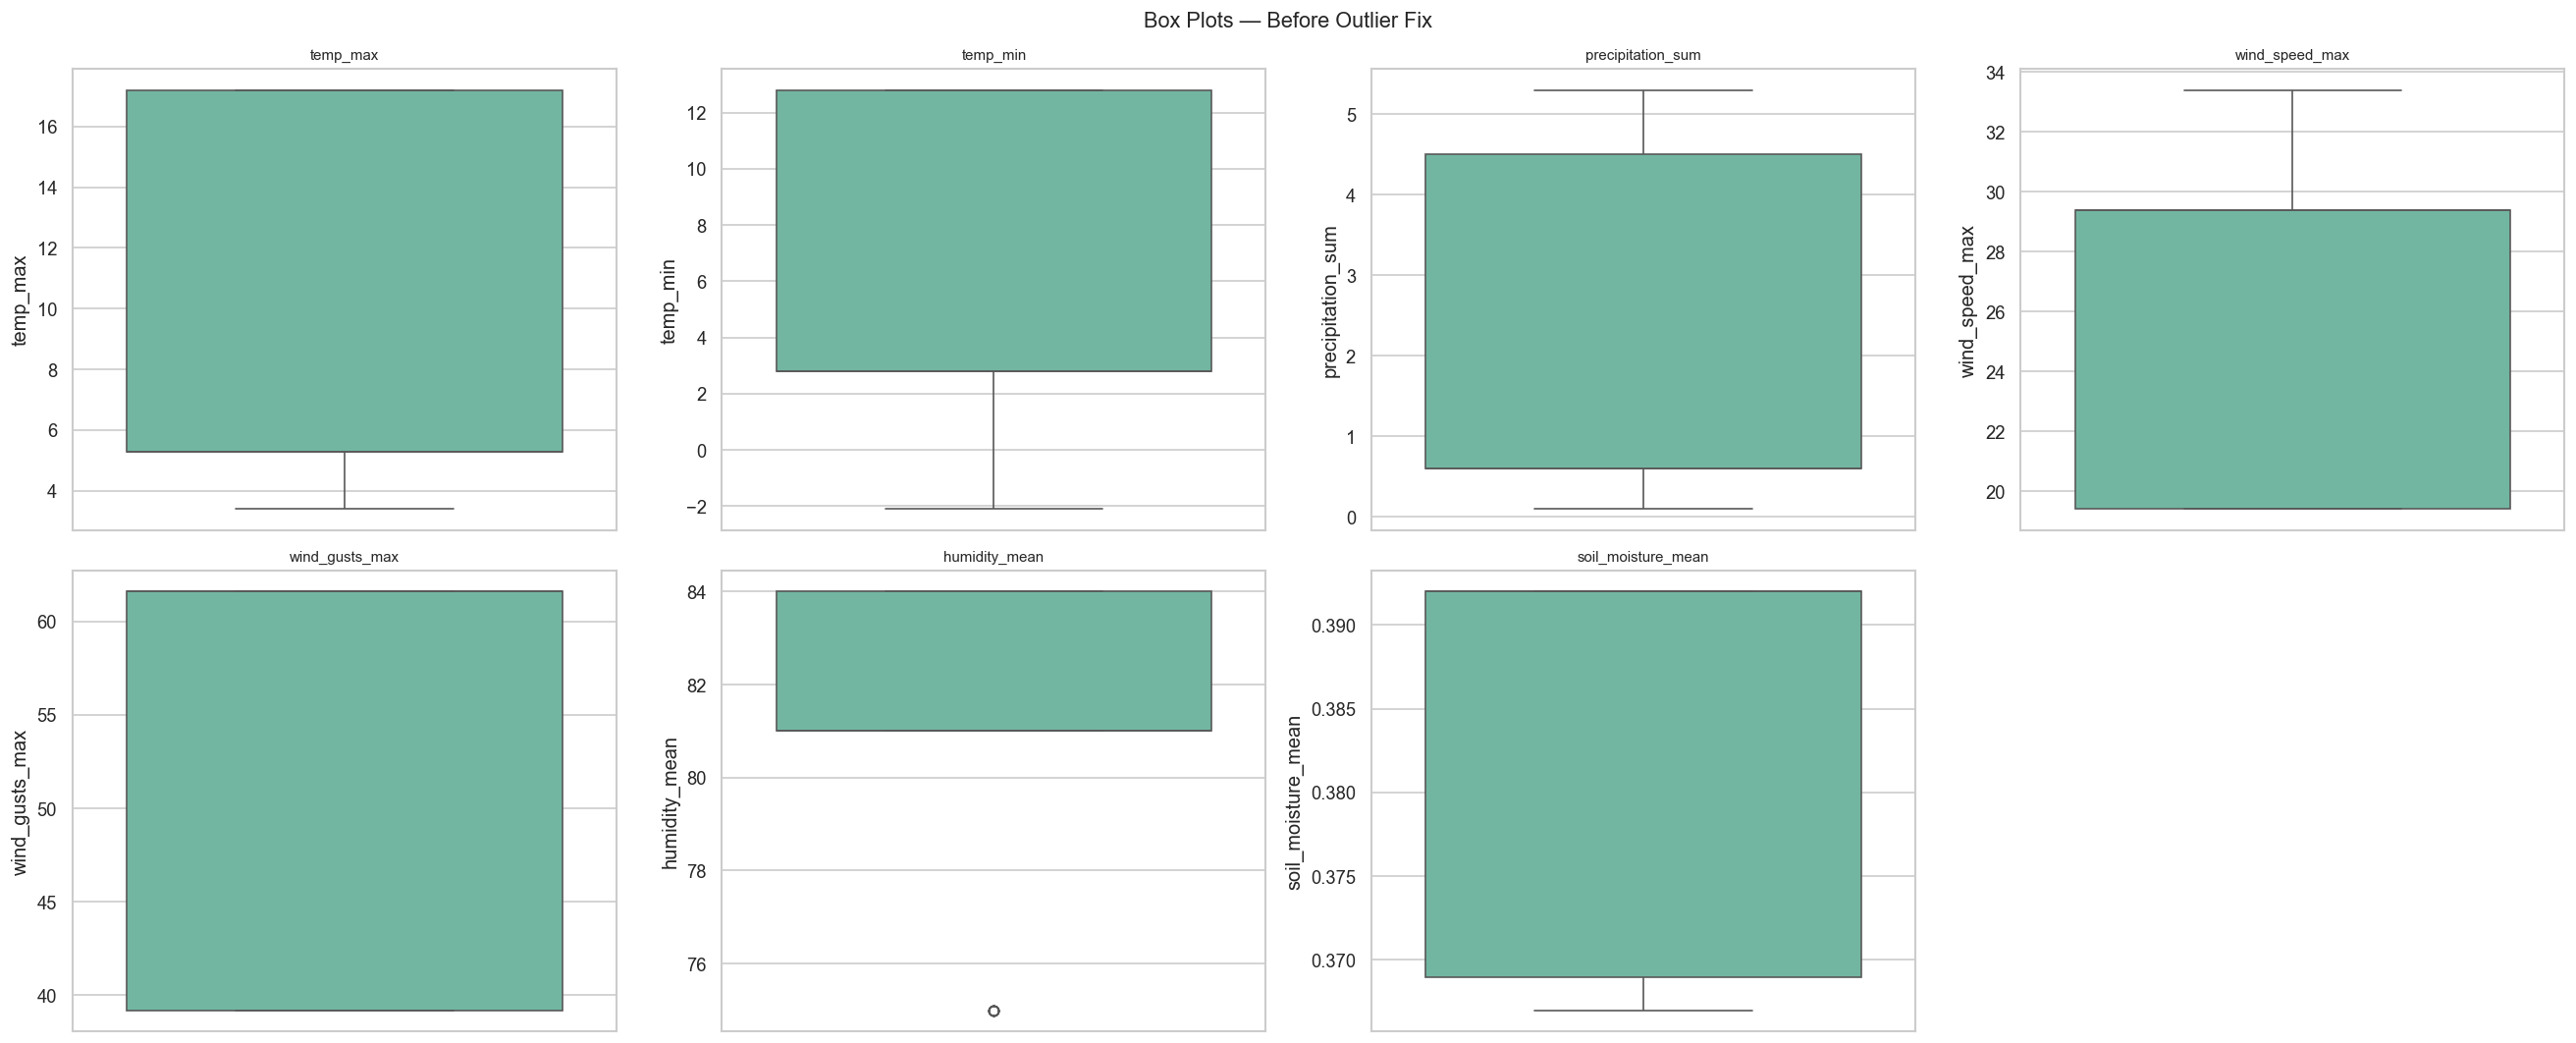

In [25]:
fig, axes = plt.subplots(2, 4, figsize=(22, 9)); axes = axes.flatten()
for i, col in enumerate(num_weather):
    sns.boxplot(data=df, y=col, palette='Set2', ax=axes[i])
    axes[i].set_title(col, fontsize=9)
axes[-1].set_visible(False)
plt.suptitle('Box Plots — Before Outlier Fix', fontsize=13)
plt.tight_layout(); plt.savefig('outliers_before.png', bbox_inches='tight'); plt.show()

### 5.2 IQR Outlier Summary

In [26]:
print(f"{'Column':<25} {'Lower':>8} {'Upper':>8} {'Outliers':>10} {'%':>6}")
print("-" * 65)
iqr_bounds = {}
for col in num_weather:
    Q1  = df[col].quantile(0.25)
    Q3  = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    n_out = ((df[col] < lower) | (df[col] > upper)).sum()
    iqr_bounds[col] = (lower, upper)
    print(f"  {col:<23} {lower:>8.3f} {upper:>8.3f} {n_out:>10,} {n_out/len(df)*100:>6.2f}%")

Column                       Lower    Upper   Outliers      %
-----------------------------------------------------------------
  temp_max                 -12.550   35.050          0   0.00%
  temp_min                 -12.200   27.800          0   0.00%
  precipitation_sum         -5.250   10.350          0   0.00%
  wind_speed_max             4.400   44.400          0   0.00%
  wind_gusts_max             5.600   95.200          0   0.00%
  humidity_mean             76.500   88.500          7   0.23%
  soil_moisture_mean         0.334    0.427          0   0.00%


### 5.3 Apply IQR Capping (Winsorisation)

In [27]:
for col in num_weather:
    lower, upper = iqr_bounds[col]
    before = df[col].copy()
    df[col] = df[col].clip(lower=lower, upper=upper)
    changed = (df[col] != before).sum()
    if changed > 0:
        print(f"  {col}: {changed} values capped")

print(f"\n✅ Outliers capped — all {len(df):,} rows preserved")

  humidity_mean: 7 values capped

✅ Outliers capped — all 2,980 rows preserved


### 5.4 Box Plots — After Capping

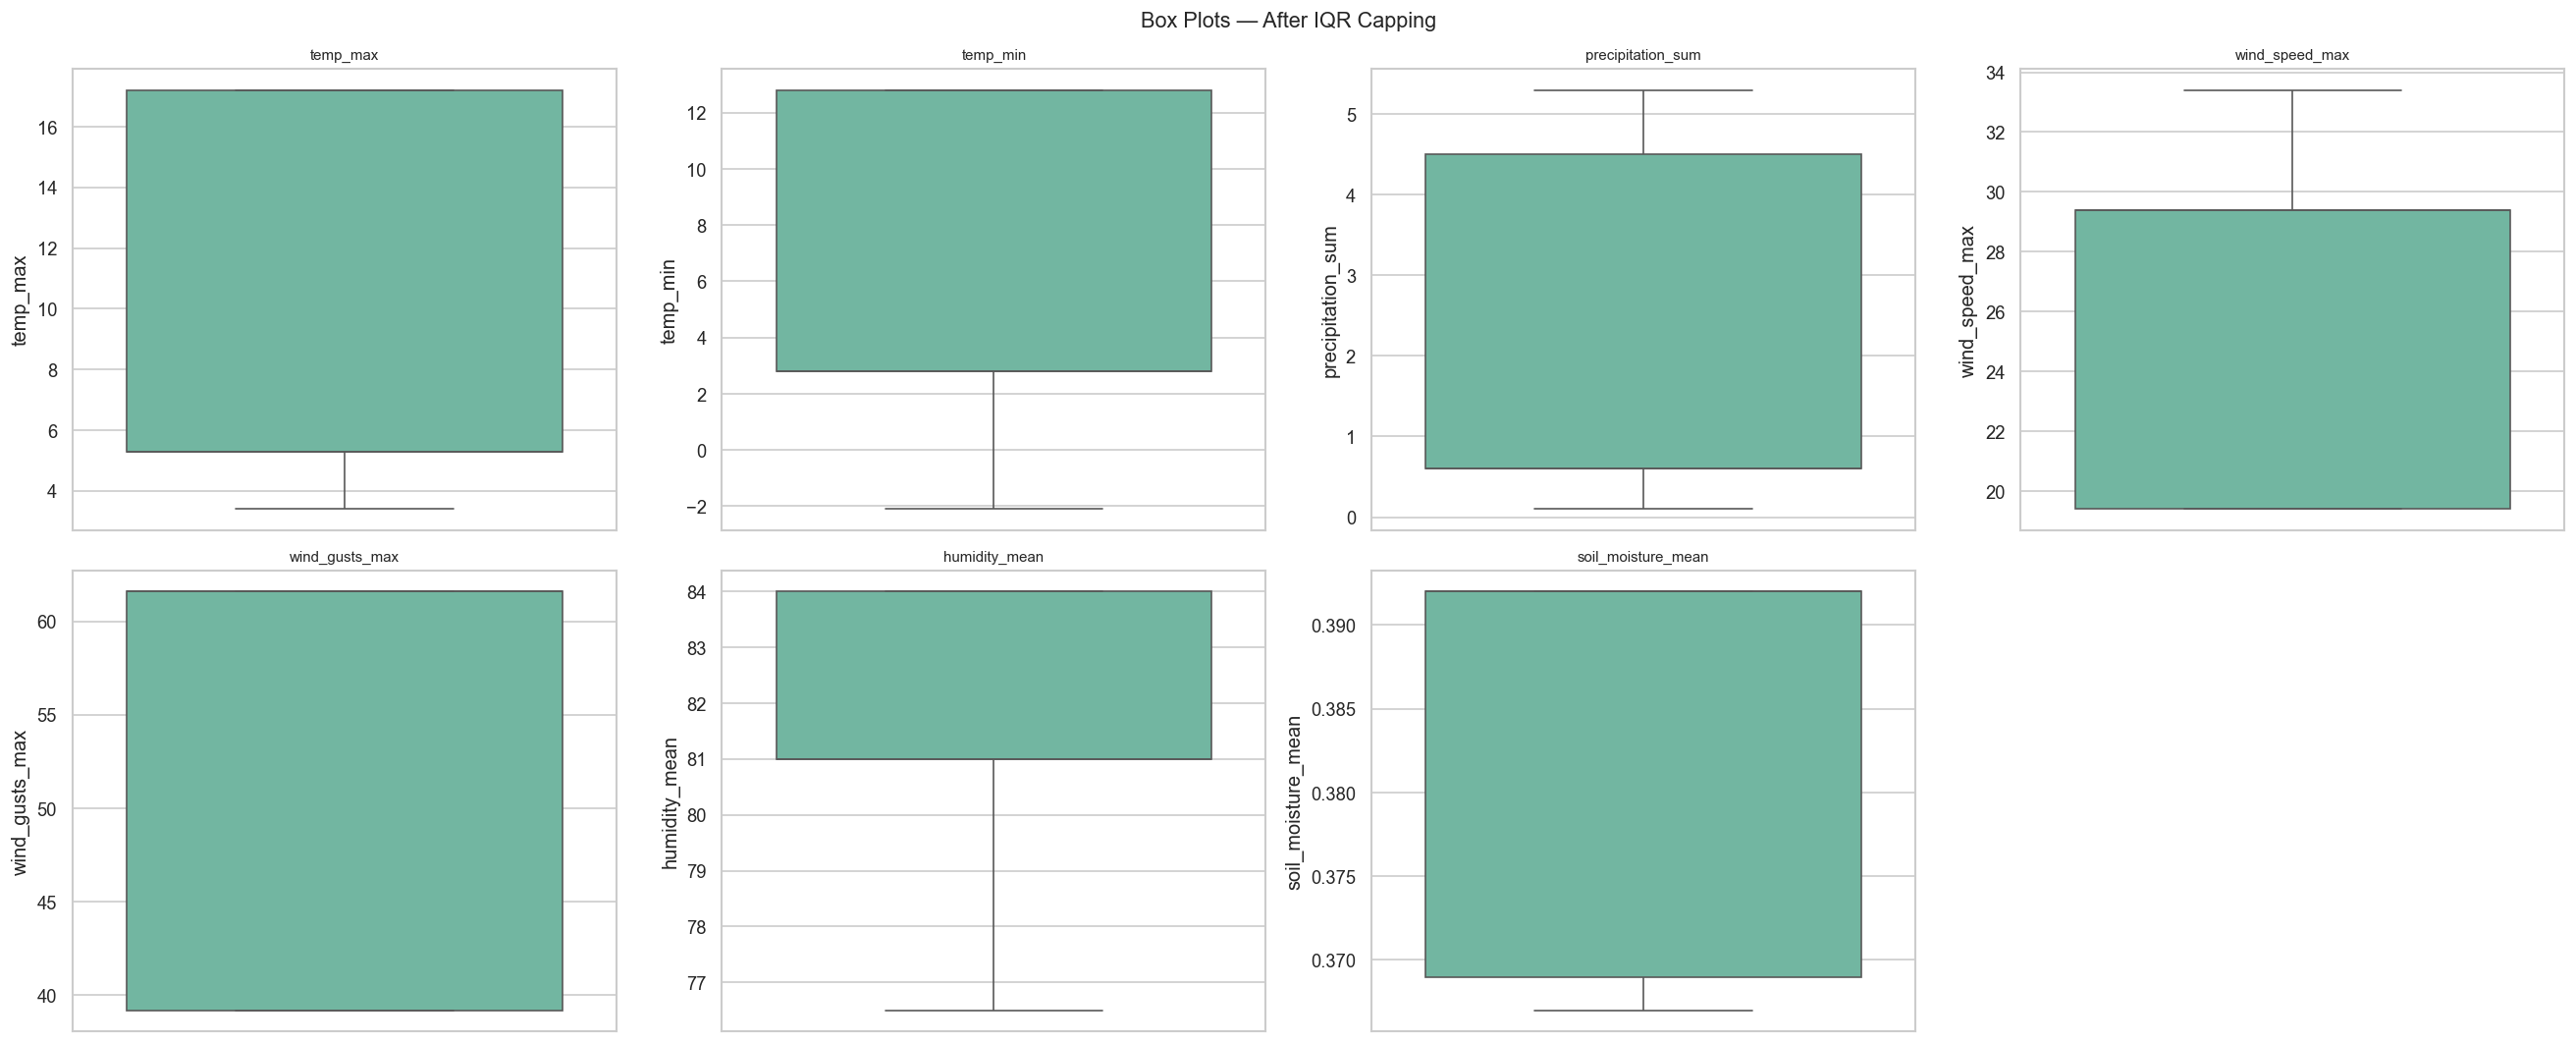

In [28]:
fig, axes = plt.subplots(2, 4, figsize=(22, 9)); axes = axes.flatten()
for i, col in enumerate(num_weather):
    sns.boxplot(data=df, y=col, palette='Set2', ax=axes[i])
    axes[i].set_title(col, fontsize=9)
axes[-1].set_visible(False)
plt.suptitle('Box Plots — After IQR Capping', fontsize=13)
plt.tight_layout(); plt.savefig('outliers_after.png', bbox_inches='tight'); plt.show()

---
## Step 6 — Pre-processing

### 6.1 One-Hot Encoding on Categorical Features

In [29]:
cat_features = ['suitability', 'town']
print(f"Categorical columns to encode: {cat_features}")
for col in cat_features:
    print(f"  {col}: {df[col].nunique()} unique values → {list(df[col].unique())[:8]}")

df_encoded = pd.get_dummies(df, columns=cat_features, drop_first=False)
print(f"\nShape before OHE: {df.shape}")
print(f"Shape after  OHE: {df_encoded.shape}")
print(f"\nNew columns added by OHE:")
new_cols = [c for c in df_encoded.columns if c not in df.columns]
print(new_cols)

Categorical columns to encode: ['suitability', 'town']
  suitability: 1 unique values → ['County to Town']
  town: 5 unique values → ['Sheffield', 'Doncaster', 'Leeds', 'Bradford', 'Newcastle upon Tyne']

Shape before OHE: (2980, 15)
Shape after  OHE: (2980, 19)

New columns added by OHE:
['suitability_County to Town', 'town_Bradford', 'town_Doncaster', 'town_Leeds', 'town_Newcastle upon Tyne', 'town_Sheffield']


### 6.2 Encode Target Variable

In [30]:
df_encoded['target'] = df_encoded['prob_4band'].map(RISK_MAPPING)
df_encoded.drop(columns=['prob_4band'], inplace=True)
print(f"Target encoding: {RISK_MAPPING}")
print(f"Target distribution:")
print(df_encoded['target'].value_counts().sort_index().rename({v:k for k,v in RISK_MAPPING.items()}).to_string())

Target encoding: {'Low': 0, 'Medium': 1, 'High': 2}
Target distribution:
target
Low       1349
Medium    1506
High       125


### 6.3 Check & Fill Remaining NaN Values

In [31]:
total_nan = df_encoded.isnull().sum()
nan_cols  = total_nan[total_nan > 0]
if len(nan_cols) == 0:
    print("✅ No missing values — nothing to fill")
else:
    print(f"Columns with NaN:\n{nan_cols.to_string()}\n")
    for col in nan_cols.index:
        if df_encoded[col].dtype == 'object':
            fill_val = df_encoded[col].mode()[0]
            df_encoded[col].fillna(fill_val, inplace=True)
            print(f"  {col}: filled with mode = '{fill_val}'")
        else:
            fill_val = df_encoded[col].mean()
            df_encoded[col].fillna(fill_val, inplace=True)
            print(f"  {col}: filled with mean = {fill_val:.4f}")
    print(f"\n✅ After fill: {df_encoded.isnull().sum().sum()} NaN remaining")

✅ No missing values — nothing to fill


In [32]:
print(f"Final dataset shape : {df_encoded.shape}")
print(f"Features            : {df_encoded.shape[1] - 1}")
print(f"Rows                : {df_encoded.shape[0]:,}")
print(f"Missing values      : {df_encoded.isnull().sum().sum()} ✅")
df_encoded.head()

Final dataset shape : (2980, 19)
Features            : 18
Rows                : 2,980
Missing values      : 0 ✅


,latitude,longitude,temp_mean,temp_max,temp_min,precipitation_sum,rain_sum,snowfall_sum,wind_speed_max,wind_gusts_max,humidity_mean,soil_moisture_mean,suitability_County to Town,town_Bradford,town_Doncaster,town_Leeds,town_Newcastle upon Tyne,town_Sheffield,target
date,,,,,,,,,,,,,,,,,,,
2009-08-01,53.391767,-1.420362,15.0,17.2,12.8,4.5,4.5,0.0,19.4,39.2,84.0,0.369,True,False,False,False,False,True,2
2009-08-01,53.646724,-0.975746,15.0,17.2,12.8,4.5,4.5,0.0,19.4,39.2,84.0,0.369,True,False,True,False,False,False,0
2009-08-01,53.613343,-0.965625,15.0,17.2,12.8,4.5,4.5,0.0,19.4,39.2,84.0,0.369,True,False,True,False,False,False,0
2009-08-01,53.795469,-1.561736,15.0,17.2,12.8,4.5,4.5,0.0,19.4,39.2,84.0,0.369,True,False,False,True,False,False,0
2009-08-01,53.795469,-1.561736,15.0,17.2,12.8,4.5,4.5,0.0,19.4,39.2,84.0,0.369,True,False,False,True,False,False,0


---
## Step 7 — Train / Test Split

In [33]:
feature_cols = [c for c in df_encoded.columns if c != 'target']
X = df_encoded[feature_cols]
y = df_encoded['target']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y)

print(f"Total samples  : {len(X):,}")
print(f"Training rows  : {len(X_train):,}  ({len(X_train)/len(X)*100:.0f}%)")
print(f"Test rows      : {len(X_test):,}   ({len(X_test)/len(X)*100:.0f}%)")
print(f"Features       : {X.shape[1]}")

print(f"\nClass distribution — Train:")
train_dist = pd.Series(y_train).map({v:k for k,v in RISK_MAPPING.items()}).value_counts()
print(train_dist.reindex(TARGET_ORDER).to_string())

print(f"\nClass distribution — Test:")
test_dist = pd.Series(y_test).map({v:k for k,v in RISK_MAPPING.items()}).value_counts()
print(test_dist.reindex(TARGET_ORDER).to_string())

Total samples  : 2,980
Training rows  : 2,384  (80%)
Test rows      : 596   (20%)
Features       : 18

Class distribution — Train:
target
Low       1079
Medium    1205
High       100

Class distribution — Test:
target
Low       270
Medium    301
High       25


---
## Step 8 — Train All Models

All models use `class_weight='balanced'` to handle class imbalance.

In [34]:
# Shared helper: fit, predict, report
def run_model(name, model, cmap='Blues'):
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    train_acc = accuracy_score(y_train, model.predict(X_train))
    test_acc  = accuracy_score(y_test, y_pred)
    gap       = train_acc - test_acc
    wf1       = f1_score(y_test, y_pred, average='weighted', zero_division=0)

    print(f"\n{'='*50}")
    print(f"  {name}")
    print(f"{'='*50}")
    print(f"  Train Accuracy : {train_acc:.4f}")
    print(f"  Test  Accuracy : {test_acc:.4f}")
    print(f"  Gap            : {gap:+.4f}")
    print(f"  Weighted F1    : {wf1:.4f}")
    print()
    print(classification_report(y_test, y_pred, target_names=CLASS_NAMES, zero_division=0))

    fig, ax = plt.subplots(figsize=(6, 5))
    ConfusionMatrixDisplay(confusion_matrix(y_test, y_pred),
                           display_labels=CLASS_NAMES).plot(cmap=cmap, ax=ax, colorbar=False)
    ax.set_title(f'{name} — Confusion Matrix', fontsize=11)
    plt.tight_layout()
    plt.savefig(f'cm_{name.lower().replace(" ","_")}.png', bbox_inches='tight')
    plt.show()

    return {'name': name, 'model': model, 'y_pred': y_pred,
            'train_acc': train_acc, 'test_acc': test_acc, 'gap': gap, 'f1': wf1}

### 8.1 Logistic Regression


  Logistic Regression
  Train Accuracy : 0.4815
  Test  Accuracy : 0.4899
  Gap            : -0.0084
  Weighted F1    : 0.3678

              precision    recall  f1-score   support

         Low       0.00      0.00      0.00       270
      Medium       0.58      0.91      0.71       301
        High       0.15      0.76      0.25        25

    accuracy                           0.49       596
   macro avg       0.24      0.56      0.32       596
weighted avg       0.30      0.49      0.37       596



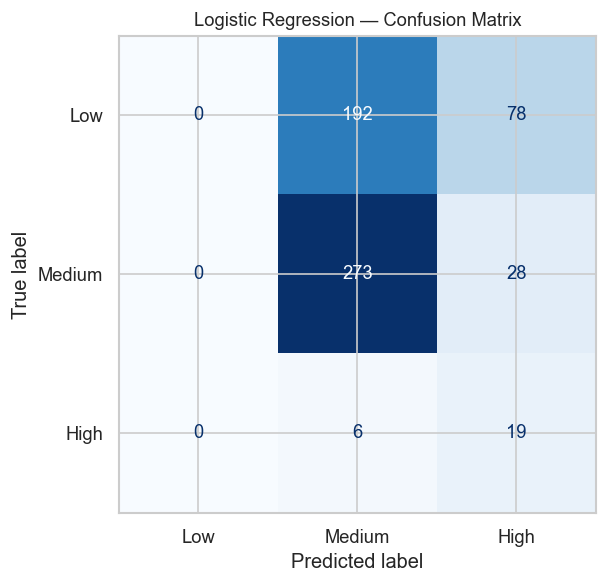

In [35]:
lr = run_model('Logistic Regression',
    LogisticRegression(max_iter=2000, class_weight='balanced',
                       C=0.5, solver='saga', random_state=RANDOM_STATE),
    cmap='Blues')

### 8.2 Random Forest


  Random Forest
  Train Accuracy : 0.8314
  Test  Accuracy : 0.7919
  Gap            : +0.0394
  Weighted F1    : 0.8000

              precision    recall  f1-score   support

         Low       0.88      0.73      0.80       270
      Medium       0.81      0.85      0.83       301
        High       0.35      0.80      0.49        25

    accuracy                           0.79       596
   macro avg       0.68      0.79      0.70       596
weighted avg       0.82      0.79      0.80       596



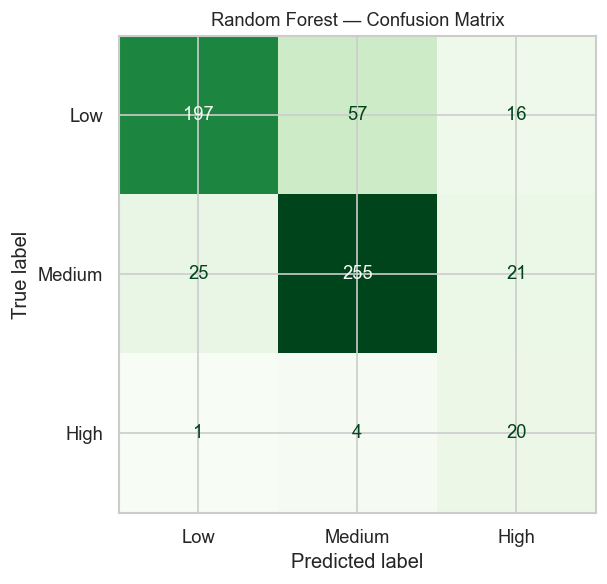

In [36]:
rf = run_model('Random Forest',
    RandomForestClassifier(n_estimators=300, max_depth=10, min_samples_leaf=10,
                           max_features='sqrt', class_weight='balanced',
                           random_state=RANDOM_STATE, n_jobs=-1),
    cmap='Greens')

### 8.3 XGBoost


  XGBoost
  Train Accuracy : 0.8637
  Test  Accuracy : 0.8154
  Gap            : +0.0482
  Weighted F1    : 0.8135

              precision    recall  f1-score   support

         Low       0.87      0.74      0.80       270
      Medium       0.78      0.90      0.84       301
        High       0.79      0.60      0.68        25

    accuracy                           0.82       596
   macro avg       0.81      0.75      0.77       596
weighted avg       0.82      0.82      0.81       596



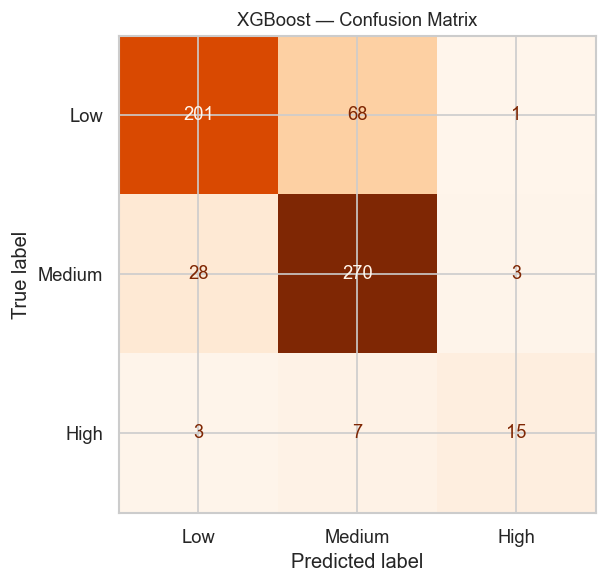

In [37]:
xgb = run_model('XGBoost',
    XGBClassifier(n_estimators=300, max_depth=4, learning_rate=0.05,
                  subsample=0.8, colsample_bytree=0.8, min_child_weight=10,
                  eval_metric='mlogloss', random_state=RANDOM_STATE,
                  n_jobs=-1, verbosity=0),
    cmap='Oranges')

### 8.4 LightGBM


  LightGBM
  Train Accuracy : 0.9027
  Test  Accuracy : 0.8339
  Gap            : +0.0688
  Weighted F1    : 0.8366

              precision    recall  f1-score   support

         Low       0.89      0.78      0.83       270
      Medium       0.83      0.89      0.86       301
        High       0.47      0.76      0.58        25

    accuracy                           0.83       596
   macro avg       0.73      0.81      0.76       596
weighted avg       0.85      0.83      0.84       596



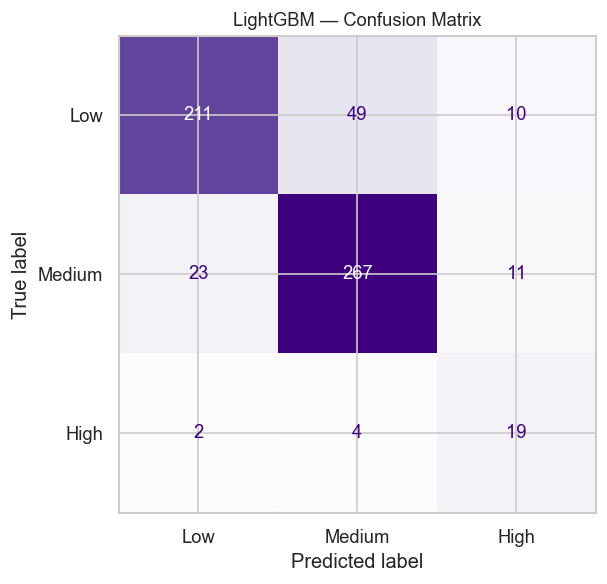

In [38]:
lgbm = run_model('LightGBM',
    LGBMClassifier(n_estimators=300, max_depth=5, learning_rate=0.05,
                   num_leaves=31, min_child_samples=20,
                   subsample=0.8, colsample_bytree=0.8,
                   class_weight='balanced', random_state=RANDOM_STATE,
                   n_jobs=-1, verbose=-1),
    cmap='Purples')

---
## Step 9 — Model Comparison

In [39]:
all_results = [lr, rf, xgb, lgbm]

summary = pd.DataFrame([{
    'Model':      r['name'],
    'Train Acc':  f"{r['train_acc']:.4f}",
    'Test Acc':   f"{r['test_acc']:.4f}",
    'Gap':        f"{r['gap']:+.4f}",
    'Weighted F1':f"{r['f1']:.4f}",
    'Status':     '⚠️ Overfit' if r['gap'] > 0.10 else '✅ Good',
} for r in all_results])

print(summary.to_string(index=False))

              Model Train Acc Test Acc     Gap Weighted F1 Status
Logistic Regression    0.4815   0.4899 -0.0084      0.3678 ✅ Good
      Random Forest    0.8314   0.7919 +0.0394      0.8000 ✅ Good
            XGBoost    0.8637   0.8154 +0.0482      0.8135 ✅ Good
           LightGBM    0.9027   0.8339 +0.0688      0.8366 ✅ Good


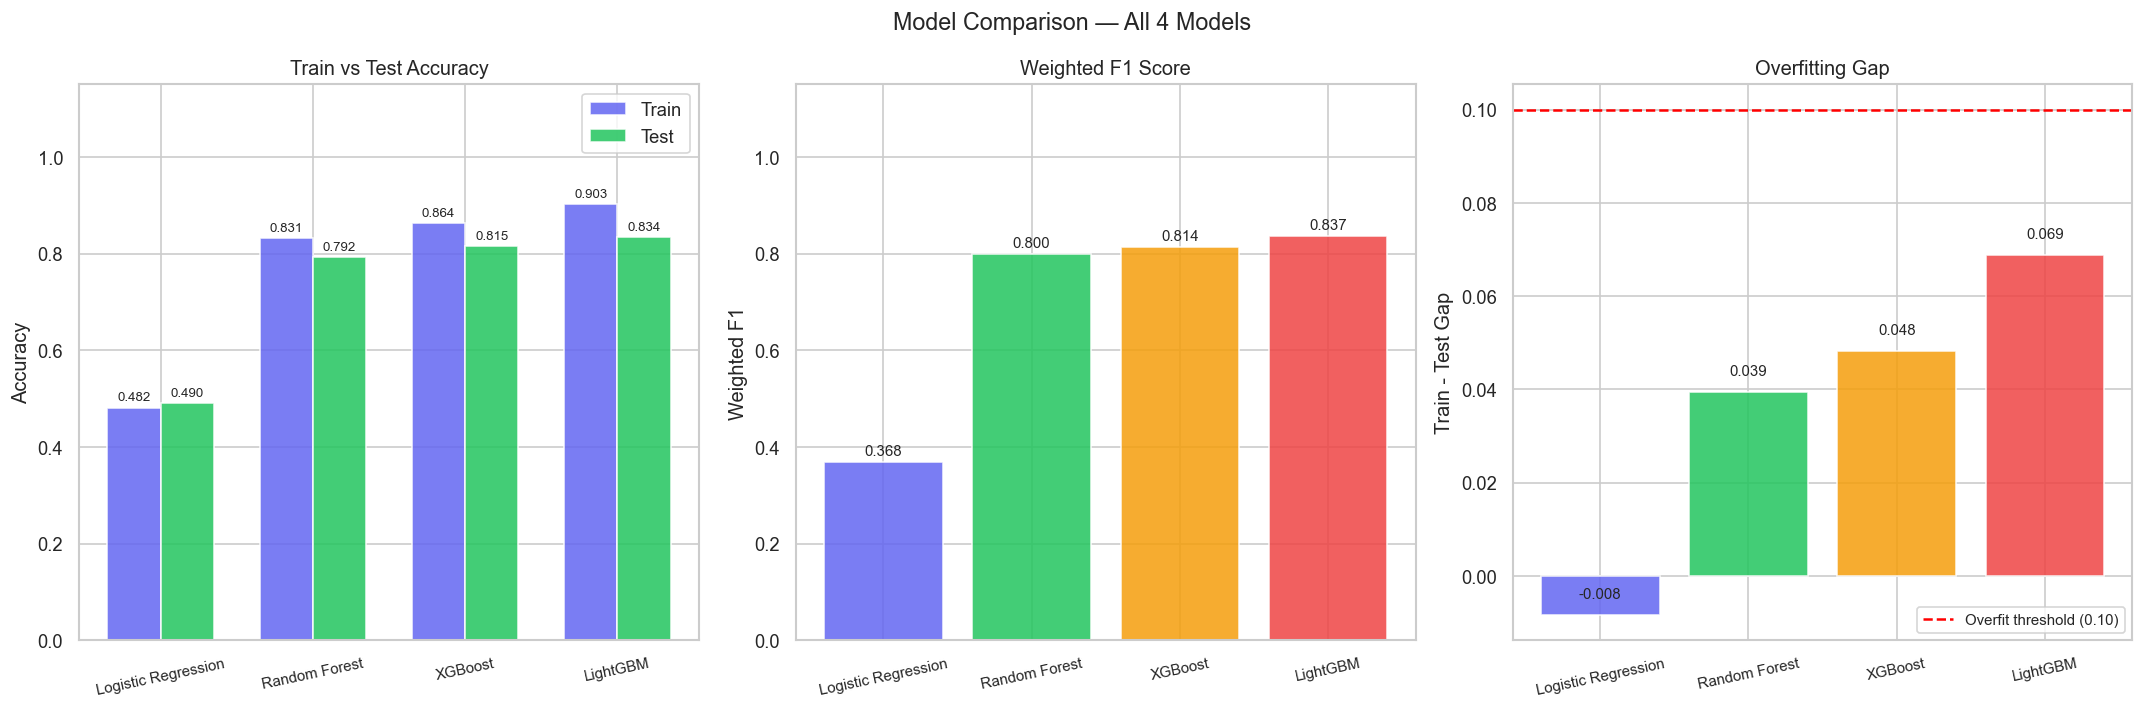

In [40]:
names  = [r['name'] for r in all_results]
trains = [r['train_acc'] for r in all_results]
tests  = [r['test_acc']  for r in all_results]
f1s    = [r['f1']        for r in all_results]
gaps   = [r['gap']       for r in all_results]

x = np.arange(len(names)); w = 0.35
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# Train vs Test Accuracy
b1 = axes[0].bar(x - w/2, trains, w, label='Train', color='#6366f1', alpha=0.85)
b2 = axes[0].bar(x + w/2, tests,  w, label='Test',  color='#22c55e', alpha=0.85)
axes[0].set_xticks(x); axes[0].set_xticklabels(names, rotation=12, fontsize=9)
axes[0].set_ylim(0, 1.15); axes[0].set_ylabel('Accuracy')
axes[0].set_title('Train vs Test Accuracy', fontsize=12); axes[0].legend()
for bar in list(b1)+list(b2):
    axes[0].text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.008,
                 f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=8)

# Weighted F1
colors4 = ['#6366f1','#22c55e','#f59e0b','#ef4444']
b3 = axes[1].bar(names, f1s, color=colors4, alpha=0.85)
axes[1].set_ylim(0, 1.15); axes[1].set_ylabel('Weighted F1')
axes[1].set_title('Weighted F1 Score', fontsize=12)
axes[1].set_xticklabels(names, rotation=12, fontsize=9)
for bar in b3:
    axes[1].text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.008,
                 f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=9)

# Train-Test Gap
b4 = axes[2].bar(names, gaps, color=colors4, alpha=0.85)
axes[2].axhline(0.10, color='red', linestyle='--', linewidth=1.5, label='Overfit threshold (0.10)')
axes[2].set_ylabel('Train - Test Gap'); axes[2].set_title('Overfitting Gap', fontsize=12)
axes[2].set_xticklabels(names, rotation=12, fontsize=9); axes[2].legend(fontsize=9)
for bar in b4:
    axes[2].text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.003,
                 f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=9)

plt.suptitle('Model Comparison — All 4 Models', fontsize=14)
plt.tight_layout(); plt.savefig('model_comparison.png', bbox_inches='tight'); plt.show()

---
## Step 10 — ROC Curves (One-vs-Rest)

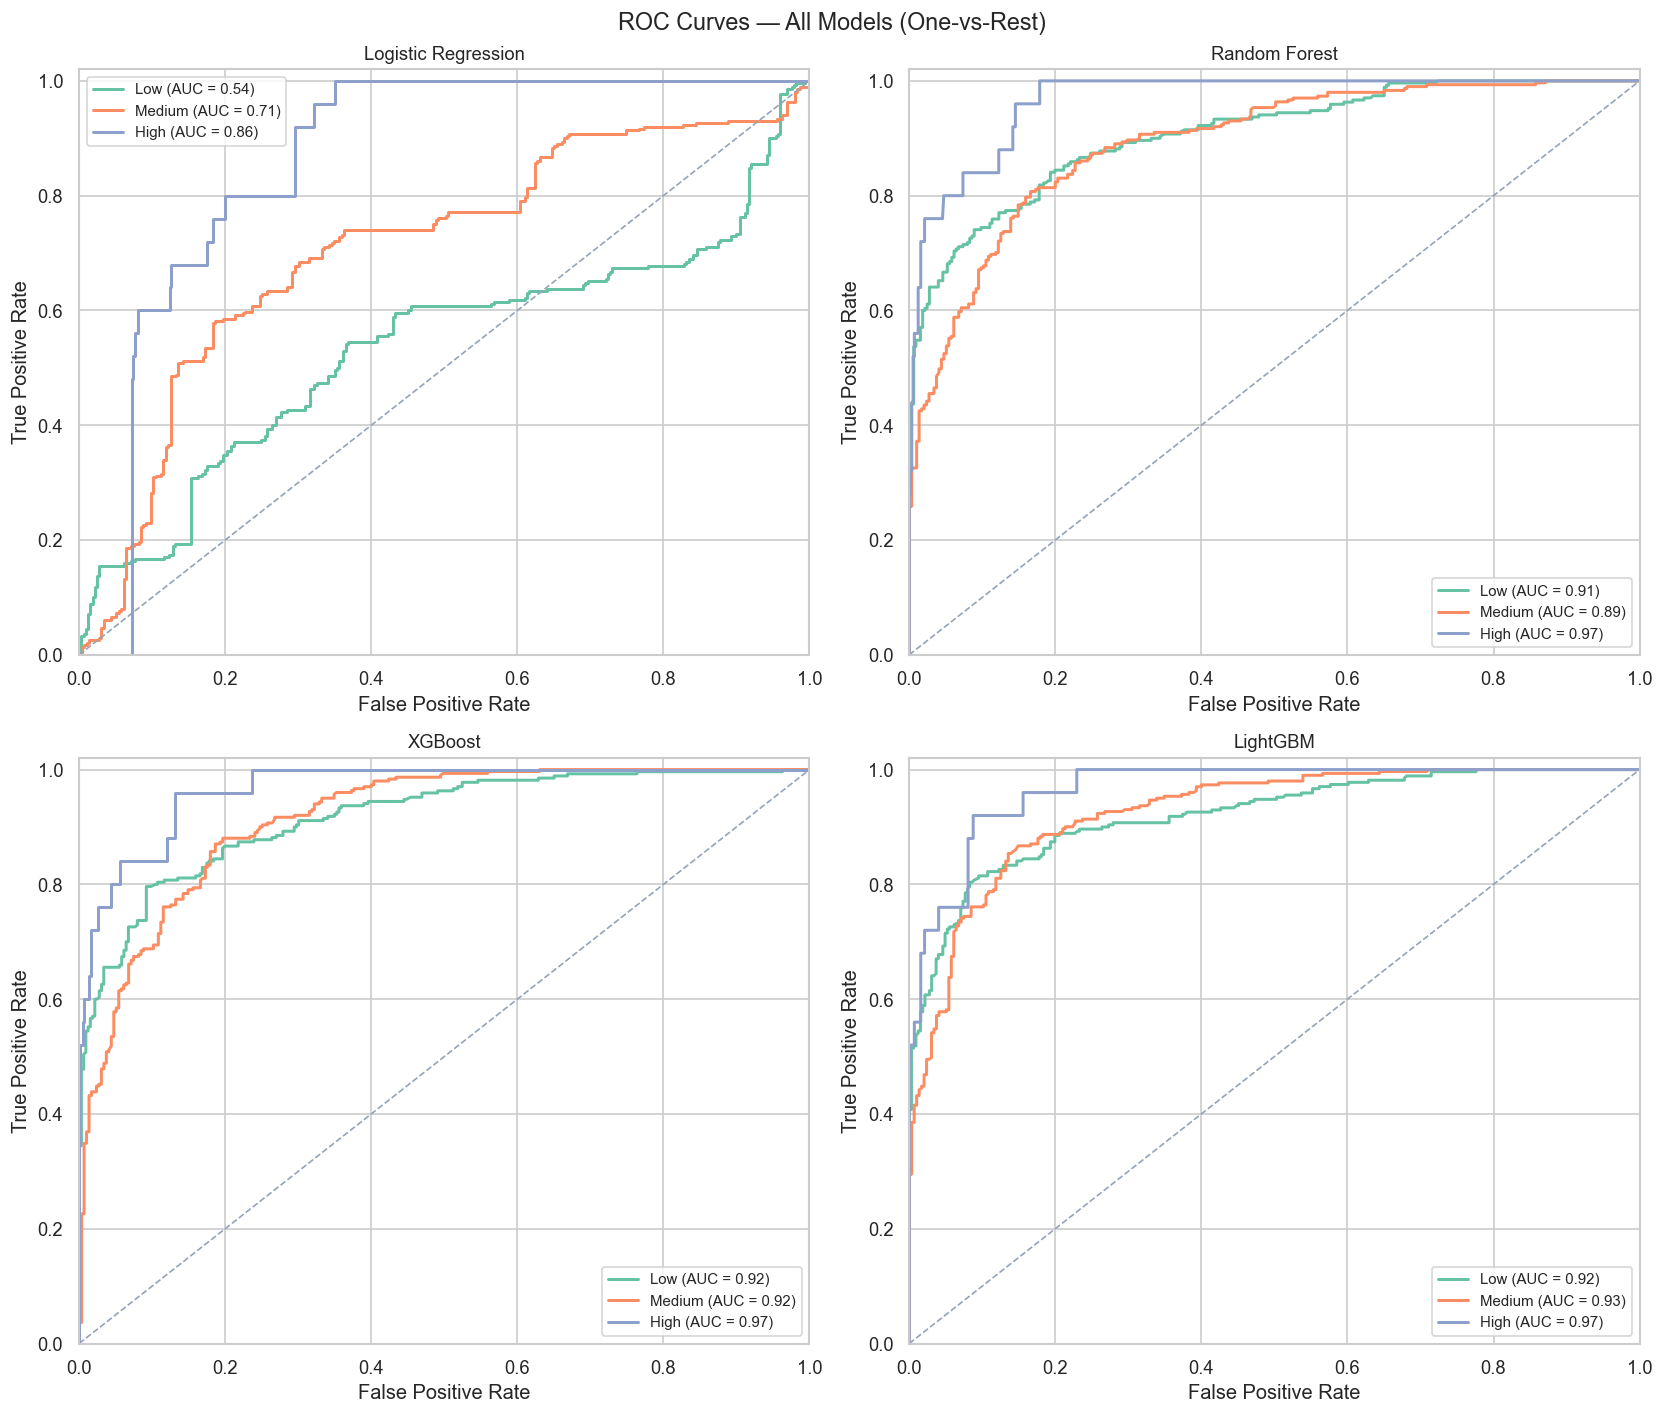

In [41]:
y_test_bin = label_binarize(y_test, classes=[0, 1, 2])

model_probs = {r['name']: r['model'].predict_proba(X_test) for r in all_results}
colors_roc  = ['#6366f1', '#22c55e', '#f59e0b', '#ef4444']

fig, axes = plt.subplots(2, 2, figsize=(14, 12)); axes = axes.flatten()

for ax, (model_name, probs), color in zip(axes, model_probs.items(), colors_roc):
    for i, cls_name in enumerate(CLASS_NAMES):
        fpr, tpr, _ = roc_curve(y_test_bin[:, i], probs[:, i])
        roc_auc = auc(fpr, tpr)
        ax.plot(fpr, tpr, linewidth=1.8, label=f'{cls_name} (AUC = {roc_auc:.2f})')
    ax.plot([0,1],[0,1], '--', color='#94a3b8', linewidth=1)
    ax.set_title(f'{model_name}', fontsize=11)
    ax.set_xlabel('False Positive Rate'); ax.set_ylabel('True Positive Rate')
    ax.legend(fontsize=9); ax.set_xlim(0,1); ax.set_ylim(0,1.02)

plt.suptitle('ROC Curves — All Models (One-vs-Rest)', fontsize=14)
plt.tight_layout(); plt.savefig('roc_curves.png', bbox_inches='tight'); plt.show()

---
## Step 11 — Best Model Selection

  🏆  Best Model: LightGBM
  Test Accuracy  : 0.8339
  Weighted F1    : 0.8366
  Train-Test Gap : +0.0688

              precision    recall  f1-score   support

         Low       0.89      0.78      0.83       270
      Medium       0.83      0.89      0.86       301
        High       0.47      0.76      0.58        25

    accuracy                           0.83       596
   macro avg       0.73      0.81      0.76       596
weighted avg       0.85      0.83      0.84       596



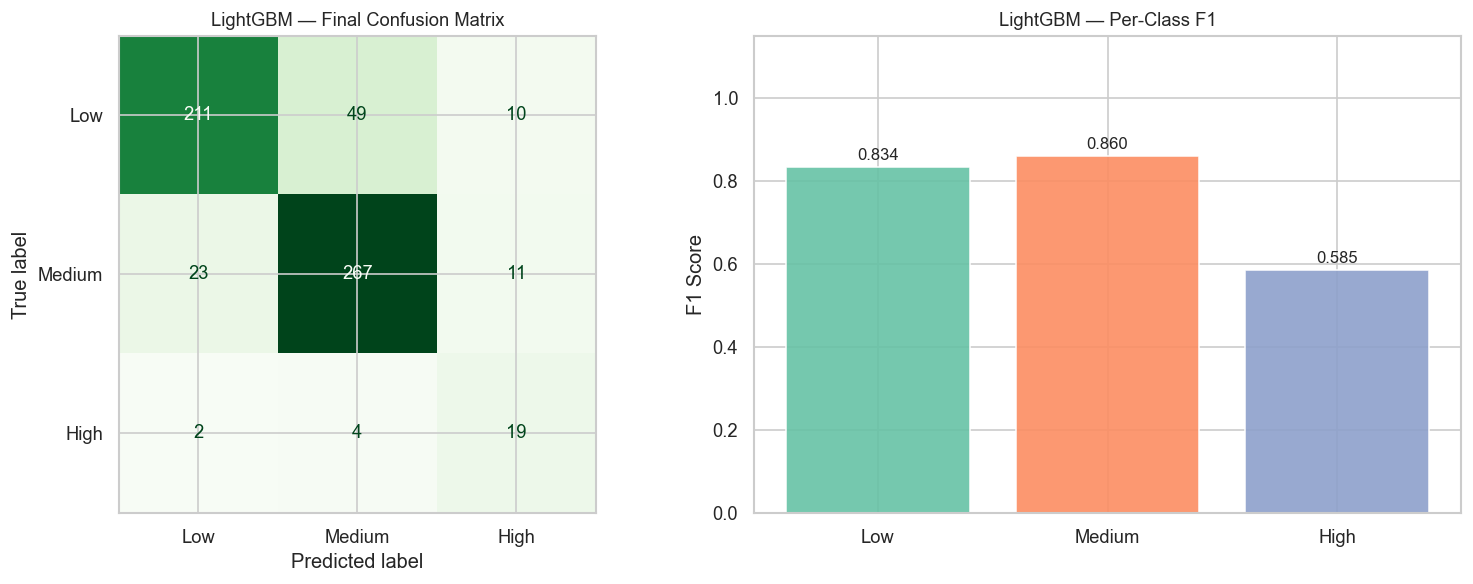

In [42]:
best = max(all_results, key=lambda r: r['f1'])
best_model = best['model']
best_name  = best['name']

print(f"{'='*45}")
print(f"  🏆  Best Model: {best_name}")
print(f"{'='*45}")
print(f"  Test Accuracy  : {best['test_acc']:.4f}")
print(f"  Weighted F1    : {best['f1']:.4f}")
print(f"  Train-Test Gap : {best['gap']:+.4f}")
print()
print(classification_report(y_test, best['y_pred'],
      target_names=CLASS_NAMES, zero_division=0))

# Final per-class F1 bar chart
from sklearn.metrics import classification_report as cr_fn
rep = cr_fn(y_test, best['y_pred'], target_names=CLASS_NAMES,
            output_dict=True, zero_division=0)
cls_f1 = [rep[c]['f1-score'] for c in CLASS_NAMES]

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
cm = confusion_matrix(y_test, best['y_pred'])
ConfusionMatrixDisplay(cm, display_labels=CLASS_NAMES).plot(
    ax=axes[0], cmap='Greens', colorbar=False)
axes[0].set_title(f'{best_name} — Final Confusion Matrix', fontsize=11)

bars = axes[1].bar(CLASS_NAMES, cls_f1,
                   color=['#66c2a5','#fc8d62','#8da0cb'], alpha=0.9)
axes[1].set_ylim(0, 1.15); axes[1].set_ylabel('F1 Score')
axes[1].set_title(f'{best_name} — Per-Class F1', fontsize=11)
for bar, f in zip(bars, cls_f1):
    axes[1].text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.01,
                 f'{f:.3f}', ha='center', va='bottom', fontsize=10)
plt.tight_layout(); plt.savefig('best_model_final.png', bbox_inches='tight'); plt.show()

---
## Step 12 — Feature Importance

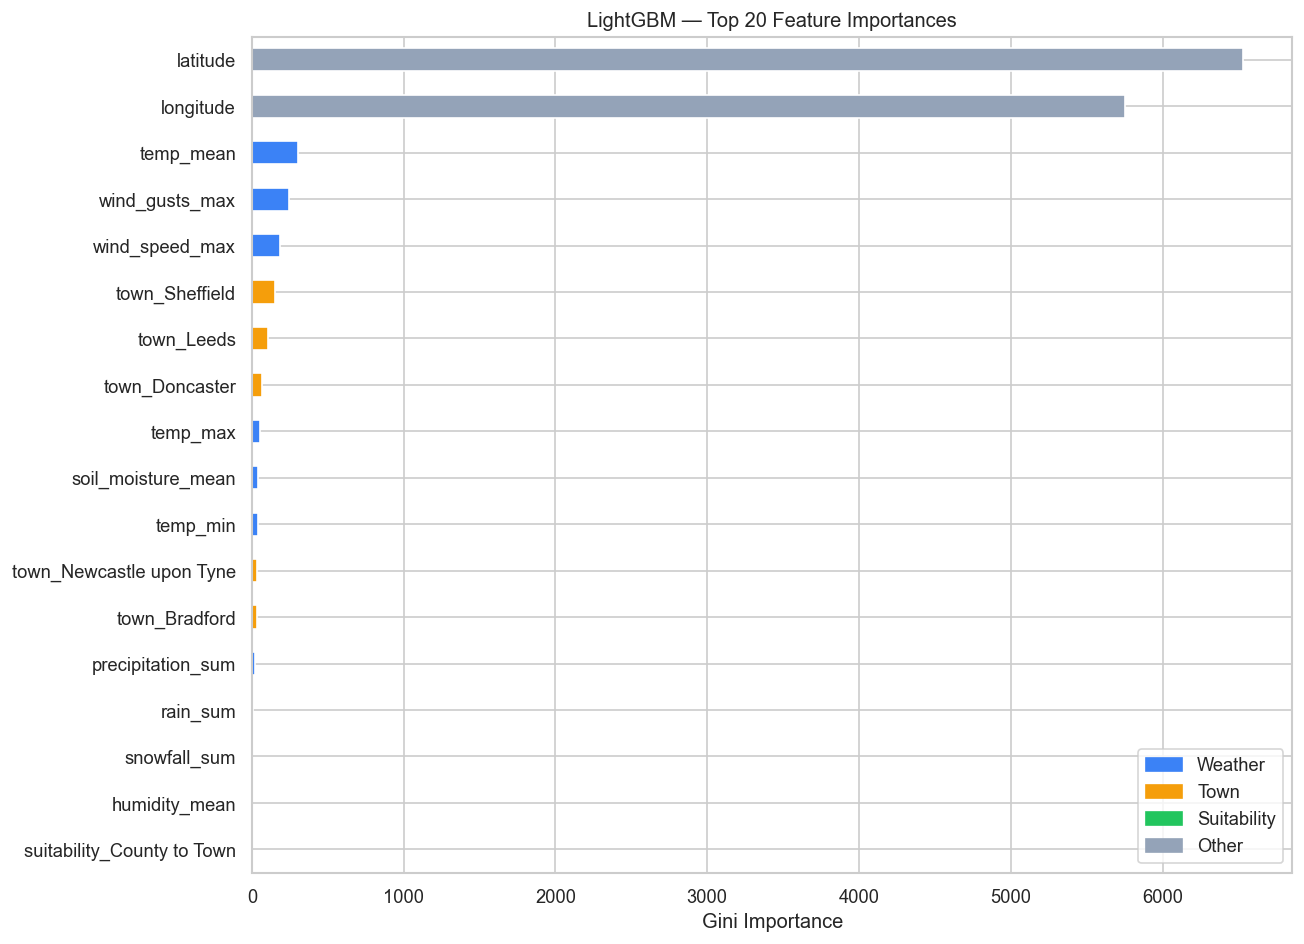


Top 10 features:


,Gini Importance
latitude,6529
longitude,5754
temp_mean,301
wind_gusts_max,244
wind_speed_max,184
town_Sheffield,150
town_Leeds,104
town_Doncaster,67
temp_max,53
soil_moisture_mean,43


In [43]:
if hasattr(best_model, 'feature_importances_'):
    fi     = pd.Series(best_model.feature_importances_, index=feature_cols)
    ylabel = 'Gini Importance'
else:
    fi     = pd.Series(np.abs(best_model.coef_).mean(axis=0), index=feature_cols)
    ylabel = 'Mean |Coefficient|'

fi = fi.sort_values(ascending=False)

def feat_color(f):
    if any(k in f for k in ['precip','rain','snow','humid','soil','wind','temp']):
        return '#3b82f6'   # blue = weather
    if f.startswith('town_'):
        return '#f59e0b'   # amber = town
    if f.startswith('suitability_'):
        return '#22c55e'   # green = suitability
    return '#94a3b8'       # grey = other

colors = [feat_color(f) for f in fi.head(20).index]
fig, ax = plt.subplots(figsize=(11, 8))
fi.head(20).plot(kind='barh', color=colors, ax=ax)
ax.invert_yaxis()
ax.set_title(f'{best_name} — Top 20 Feature Importances', fontsize=12)
ax.set_xlabel(ylabel)
patches = [mpatches.Patch(color='#3b82f6', label='Weather'),
           mpatches.Patch(color='#f59e0b', label='Town'),
           mpatches.Patch(color='#22c55e', label='Suitability'),
           mpatches.Patch(color='#94a3b8', label='Other')]
ax.legend(handles=patches, loc='lower right')
plt.tight_layout(); plt.savefig('feature_importance.png', bbox_inches='tight'); plt.show()

print(f"\nTop 10 features:")
display(fi.head(10).to_frame(ylabel).round(4))

---
## Step 13 — Test with Random Samples

Create 5 synthetic test rows by sampling from the actual feature distributions.  
This simulates new, unseen inputs and checks the model's predictions.

In [44]:
np.random.seed(42)
n_samples = 5

# Sample random rows from the test set (realistic, unseen to the model during fitting)
random_indices = np.random.choice(len(X_test), size=n_samples, replace=False)
X_random = X_test.iloc[random_indices].copy()
y_random_true = y_test.iloc[random_indices].values

# Predict
y_random_pred = best_model.predict(X_random)
y_random_prob = best_model.predict_proba(X_random)

label_map = {v: k for k, v in RISK_MAPPING.items()}
print(f"Random Sample Predictions — {best_name}")
print("="*80)
print(f"{'Sample':>8} {'True Label':<14} {'Predicted':<14} {'Confidence':>12}  {'Match'}")
print("-"*80)
for i in range(n_samples):
    true_lbl = label_map[y_random_true[i]]
    pred_lbl = label_map[y_random_pred[i]]
    conf     = y_random_prob[i, y_random_pred[i]]
    match    = "✅" if y_random_true[i] == y_random_pred[i] else "❌"
    print(f"  {i+1:>6}   {true_lbl:<14} {pred_lbl:<14} {conf:>11.1%}  {match}")

print()
print(f"Accuracy on these {n_samples} samples: "
      f"{(y_random_true == y_random_pred).mean():.0%}")

Random Sample Predictions — LightGBM
  Sample True Label     Predicted        Confidence  Match
--------------------------------------------------------------------------------
       1   Low            Low                  98.0%  ✅
       2   Low            Medium               61.8%  ❌
       3   Medium         Medium               84.9%  ✅
       4   Low            Low                  96.1%  ✅
       5   Low            Medium               69.3%  ❌

Accuracy on these 5 samples: 60%


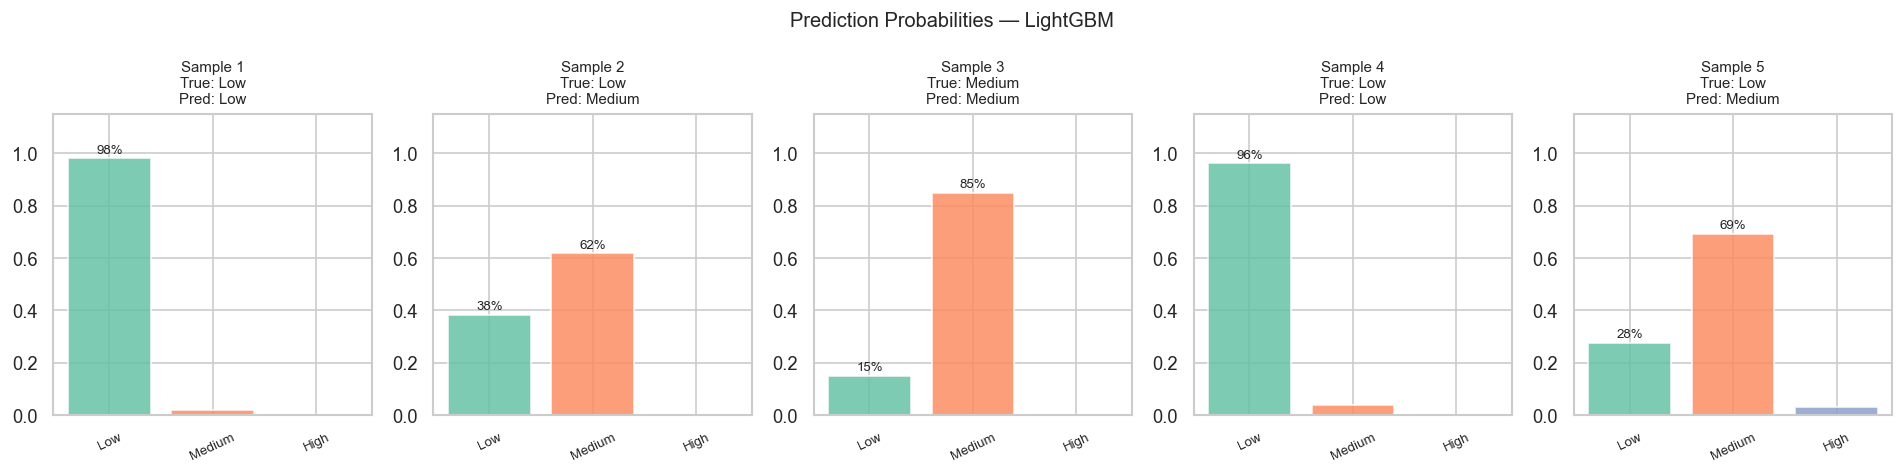

In [45]:
# Probability breakdown for each random sample
fig, axes = plt.subplots(1, n_samples, figsize=(16, 4))
for i, ax in enumerate(axes):
    probs = y_random_prob[i]
    bars  = ax.bar(CLASS_NAMES, probs,
                   color=['#66c2a5','#fc8d62','#8da0cb'], alpha=0.85)
    true_lbl = label_map[y_random_true[i]]
    pred_lbl = label_map[y_random_pred[i]]
    ax.set_ylim(0, 1.15)
    ax.set_title(f'Sample {i+1}\nTrue: {true_lbl}\nPred: {pred_lbl}', fontsize=9)
    ax.set_xticklabels(CLASS_NAMES, rotation=25, fontsize=8)
    for bar, p in zip(bars, probs):
        if p > 0.05:
            ax.text(bar.get_x()+bar.get_width()/2, p+0.02,
                    f'{p:.0%}', ha='center', fontsize=8)
plt.suptitle(f'Prediction Probabilities — {best_name}', fontsize=12)
plt.tight_layout(); plt.savefig('random_sample_predictions.png', bbox_inches='tight'); plt.show()

---
## Step 14 — Train vs Test Performance Comparison

Full breakdown of how all 4 models perform on training data vs test data.

In [46]:
metrics_rows = []
for r in all_results:
    y_tr_pred = r['model'].predict(X_train)
    y_te_pred = r['y_pred']
    metrics_rows.append({
        'Model':         r['name'],
        'Train Acc':     accuracy_score(y_train, y_tr_pred),
        'Test Acc':      r['test_acc'],
        'Train F1':      f1_score(y_train, y_tr_pred, average='weighted', zero_division=0),
        'Test F1':       r['f1'],
        'Train Prec':    precision_score(y_train, y_tr_pred, average='weighted', zero_division=0),
        'Test Prec':     precision_score(y_test,  y_te_pred, average='weighted', zero_division=0),
        'Train Recall':  recall_score(y_train, y_tr_pred, average='weighted', zero_division=0),
        'Test Recall':   recall_score(y_test,  y_te_pred, average='weighted', zero_division=0),
        'Gap (Acc)':     r['gap'],
    })

comp_df = pd.DataFrame(metrics_rows).set_index('Model')

styled = (comp_df.style
    .format('{:.4f}')
    .background_gradient(cmap='YlGn', subset=['Test Acc','Test F1'])
    .background_gradient(cmap='YlOrRd', subset=['Gap (Acc)'])
    .set_caption('Train vs Test — All Metrics'))
display(styled)

,Train Acc,Test Acc,Train F1,Test F1,Train Prec,Test Prec,Train Recall,Test Recall,Gap (Acc)
Model,,,,,,,,,
Logistic Regression,0.4815,0.4899,0.3610,0.3678,0.2937,0.2991,0.4815,0.4899,-0.0084
Random Forest,0.8314,0.7919,0.8382,0.8000,0.8595,0.8225,0.8314,0.7919,0.0394
XGBoost,0.8637,0.8154,0.8621,0.8135,0.8667,0.8208,0.8637,0.8154,0.0482
LightGBM,0.9027,0.8339,0.9030,0.8366,0.9061,0.8463,0.9027,0.8339,0.0688


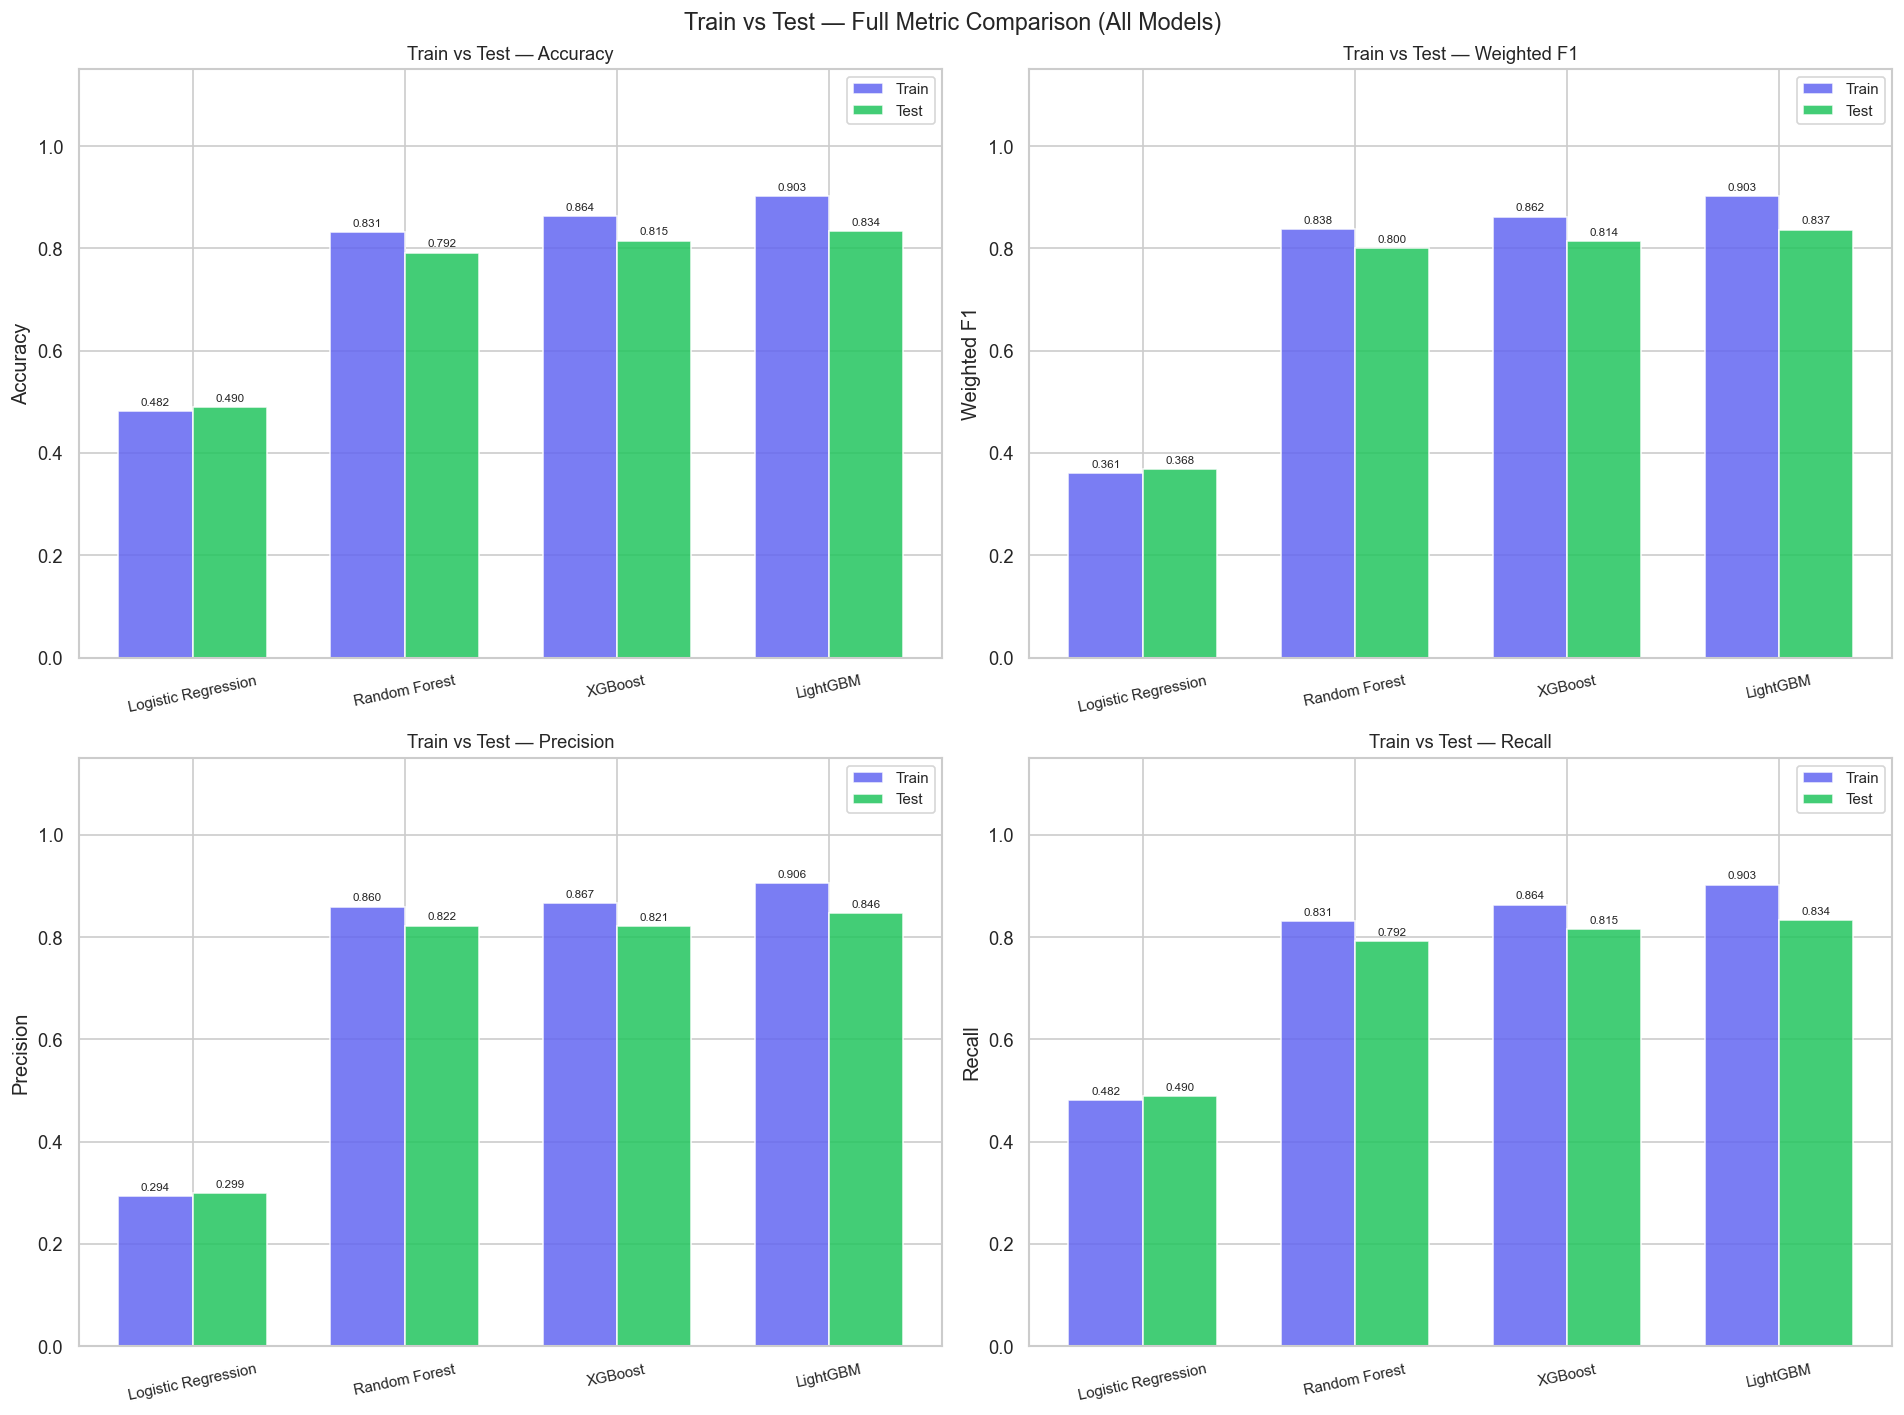

In [47]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
metric_pairs = [
    ('Train Acc',   'Test Acc',    'Accuracy'),
    ('Train F1',    'Test F1',     'Weighted F1'),
    ('Train Prec',  'Test Prec',   'Precision'),
    ('Train Recall','Test Recall', 'Recall'),
]
colors_train = '#6366f1'; colors_test = '#22c55e'
model_names  = comp_df.index.tolist()
x = np.arange(len(model_names)); w = 0.35

for ax, (tr_col, te_col, title) in zip(axes.flatten(), metric_pairs):
    b1 = ax.bar(x - w/2, comp_df[tr_col], w, label='Train',
                color=colors_train, alpha=0.85)
    b2 = ax.bar(x + w/2, comp_df[te_col], w, label='Test',
                color=colors_test, alpha=0.85)
    ax.set_xticks(x); ax.set_xticklabels(model_names, rotation=12, fontsize=9)
    ax.set_ylim(0, 1.15); ax.set_ylabel(title)
    ax.set_title(f'Train vs Test — {title}', fontsize=11); ax.legend(fontsize=9)
    for bar in list(b1)+list(b2):
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.007,
                f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=7)

plt.suptitle('Train vs Test — Full Metric Comparison (All Models)', fontsize=14)
plt.tight_layout(); plt.savefig('train_vs_test_comparison.png', bbox_inches='tight'); plt.show()

In [48]:
print("\n" + "="*55)
print("  FINAL SUMMARY")
print("="*55)
print(f"  Dataset rows used   : {len(df_encoded):,}")
print(f"  Features            : {len(feature_cols)}")
print(f"  Towns kept          : {top5_towns}")
print(f"  Train / Test split  : {len(X_train):,} / {len(X_test):,}")
print()
print(f"  {'Model':<22} {'Test Acc':>9} {'Test F1':>9} {'Gap':>8}")
print(f"  {'-'*52}")
for r in sorted(all_results, key=lambda r: r['f1'], reverse=True):
    flag = ' 🏆' if r['name'] == best_name else ''
    print(f"  {r['name']:<22} {r['test_acc']:>9.4f} {r['f1']:>9.4f} {r['gap']:>+8.4f}{flag}")
print()
print(f"  🏆  Best model: {best_name}")
print(f"     Test F1   : {best['f1']:.4f}")
print(f"     Test Acc  : {best['test_acc']:.4f}")


  FINAL SUMMARY
  Dataset rows used   : 2,980
  Features            : 18
  Towns kept          : ['Leeds', 'Sheffield', 'Bradford', 'Doncaster', 'Newcastle upon Tyne']
  Train / Test split  : 2,384 / 596

  Model                   Test Acc   Test F1      Gap
  ----------------------------------------------------
  LightGBM                  0.8339    0.8366  +0.0688 🏆
  XGBoost                   0.8154    0.8135  +0.0482
  Random Forest             0.7919    0.8000  +0.0394
  Logistic Regression       0.4899    0.3678  -0.0084

  🏆  Best model: LightGBM
     Test F1   : 0.8366
     Test Acc  : 0.8339


In [49]:
import shap

# Use 300 test rows for speed — representative sample
X_sample = X_test.iloc[:300]

# TreeExplainer works natively with Random Forest, XGBoost, LightGBM
explainer   = shap.TreeExplainer(best_model)
shap_values = explainer.shap_values(X_sample)

# SHAP returns different formats depending on version and model type:
#   Old format : list of arrays, one per class  →  shap_values[class_idx]
#   New format : 3-D array (samples, features, classes)  →  shap_values[:, :, class_idx]
# We target class 2 = "High" risk (most important for flood warning)
if isinstance(shap_values, list):
    sv = shap_values[2]            # shape → (n_samples, n_features)
elif shap_values.ndim == 3:
    sv = shap_values[:, :, 2]      # shape → (n_samples, n_features)
else:
    sv = shap_values               # binary or single output

print(f"✅ SHAP computed — target class: High risk (class 2)")
print(f"   SHAP matrix shape : {sv.shape}")
print(f"   Features           : {sv.shape[1]}")


✅ SHAP computed — target class: High risk (class 2)
   SHAP matrix shape : (300, 18)
   Features           : 18


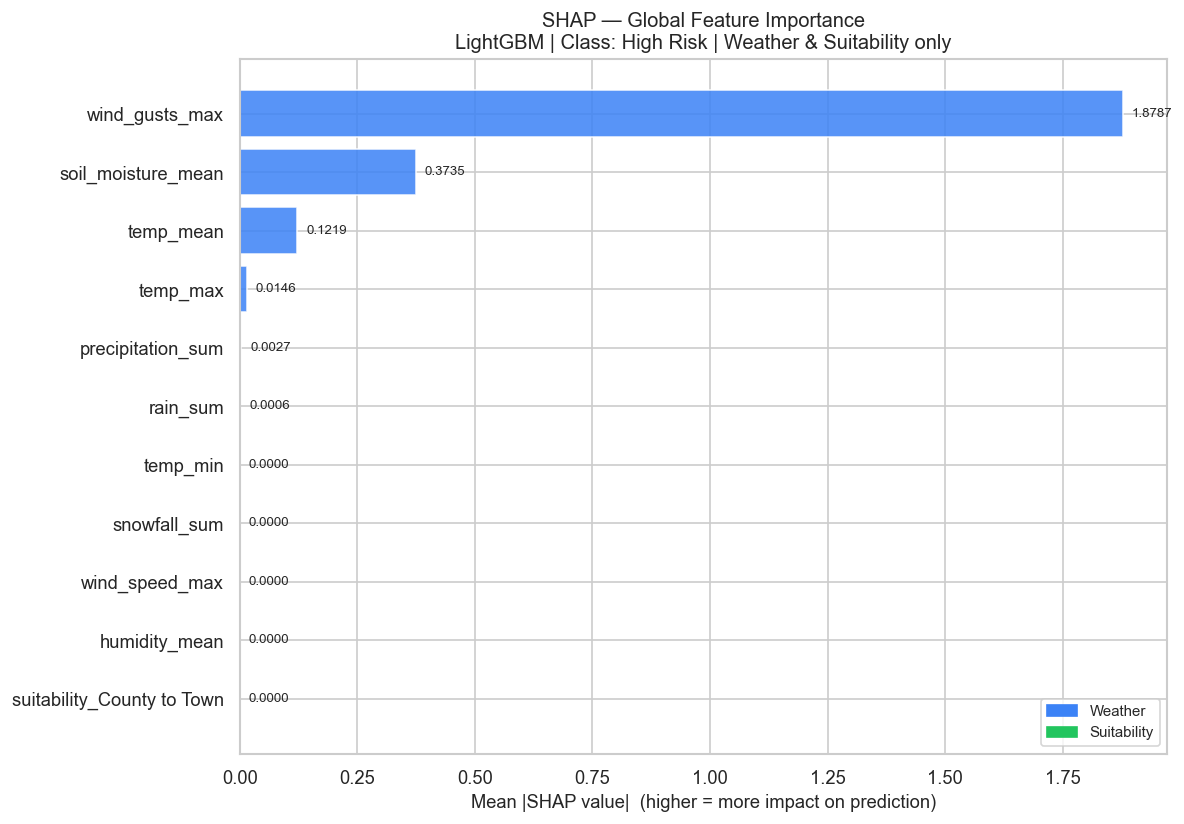

In [50]:
# ── Global SHAP Bar Chart ────────────────────────────────────────────────────
# Mean absolute SHAP value per feature = average impact across all samples
mean_shap = np.abs(sv).mean(axis=0)   # always 1-D: (n_features,)

# Features excluded from all SHAP plots:
#   town_*    — geographic identity (which town) — not an actionable weather driver
#   latitude  — geographic coordinate — redundant with town OHE for explanation purposes
#   longitude — geographic coordinate — redundant with town OHE for explanation purposes
GEO_EXCLUDE = {'latitude', 'longitude'}

shap_df = pd.DataFrame({'feature': X_sample.columns, 'mean_shap': mean_shap})
shap_df = shap_df[
    ~shap_df['feature'].str.startswith('town_') &
    ~shap_df['feature'].isin(GEO_EXCLUDE)
]
shap_df = shap_df.sort_values('mean_shap', ascending=False).head(15)

def shap_feat_color(f):
    if any(k in f for k in ['temp','precip','rain','snow','humid','soil','wind']):
        return '#3b82f6'   # blue = weather feature
    if f.startswith('suitability_'):
        return '#22c55e'   # green = suitability
    return '#94a3b8'       # grey = other

colors = [shap_feat_color(f) for f in shap_df['feature']]

fig, ax = plt.subplots(figsize=(10, 7))
bars = ax.barh(shap_df['feature'], shap_df['mean_shap'], color=colors, alpha=0.85)
ax.invert_yaxis()
ax.set_xlabel('Mean |SHAP value|  (higher = more impact on prediction)', fontsize=11)
ax.set_title(f'SHAP — Global Feature Importance\n{best_name} | Class: High Risk | Weather & Suitability only',
             fontsize=12)
for bar, val in zip(bars, shap_df['mean_shap']):
    ax.text(val + shap_df['mean_shap'].max() * 0.01,
            bar.get_y() + bar.get_height() / 2,
            f'{val:.4f}', va='center', fontsize=8)

patches = [mpatches.Patch(color='#3b82f6', label='Weather'),
           mpatches.Patch(color='#22c55e', label='Suitability')]
ax.legend(handles=patches, loc='lower right', fontsize=9)
plt.tight_layout(); plt.savefig('shap_global.png', bbox_inches='tight'); plt.show()


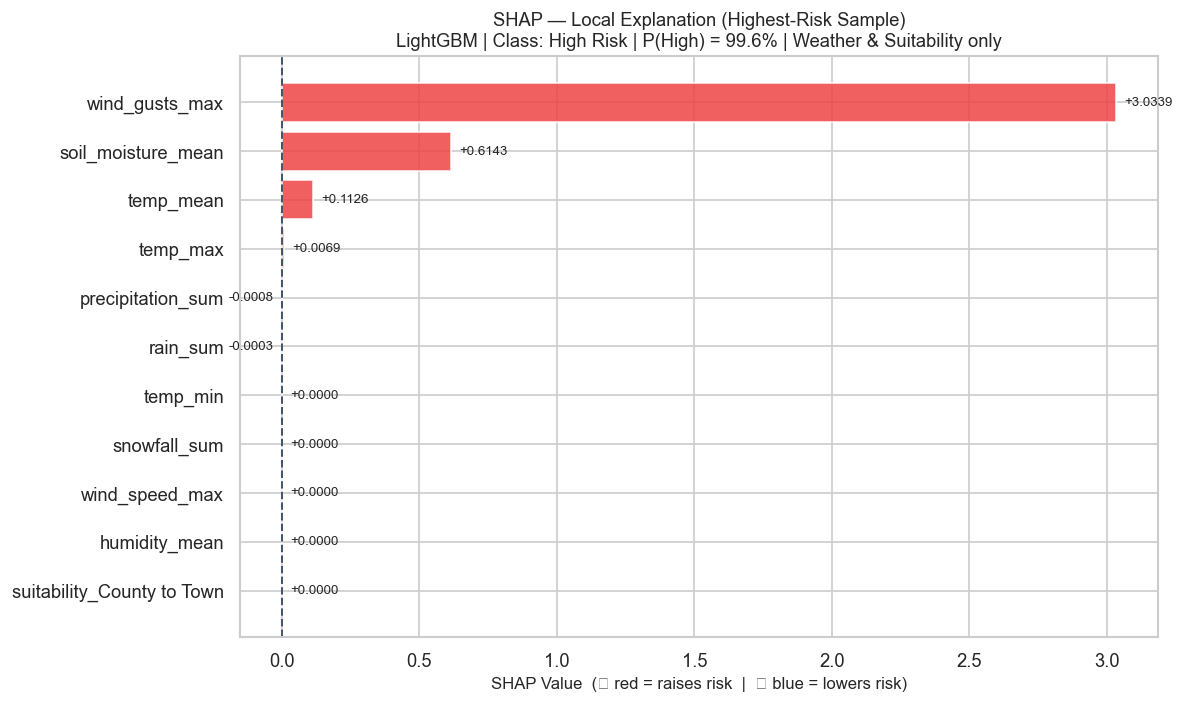

Sample predicted P(High) = 99.6%
Sample true label        = High


In [51]:
# ── Local Waterfall — single highest-risk sample ────────────────────────────
probs         = best_model.predict_proba(X_test)
high_risk_idx = int(np.argmax(probs[:, 2]))      # class 2 = High

# Recompute SHAP for just that one row
sv_single = explainer.shap_values(X_test.iloc[[high_risk_idx]])

if isinstance(sv_single, list):
    sv_row = sv_single[2][0]
elif sv_single.ndim == 3:
    sv_row = sv_single[0, :, 2]
else:
    sv_row = sv_single[0]

# Exclude town columns, latitude, and longitude — keep weather + suitability only
GEO_EXCLUDE = {'latitude', 'longitude'}
sv_series = pd.Series(sv_row, index=X_test.columns)
sv_series = sv_series[
    ~sv_series.index.str.startswith('town_') &
    ~sv_series.index.isin(GEO_EXCLUDE)
]
sv_series = sv_series.sort_values(key=abs, ascending=False).head(12)

bar_colors = ['#ef4444' if v > 0 else '#3b82f6' for v in sv_series.values]

fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.barh(sv_series.index, sv_series.values, color=bar_colors, alpha=0.85)
ax.invert_yaxis()
ax.axvline(0, color='#475569', linewidth=1.2, linestyle='--')
ax.set_xlabel('SHAP Value  (🔴 red = raises risk  |  🔵 blue = lowers risk)', fontsize=10)
ax.set_title(f'SHAP — Local Explanation (Highest-Risk Sample)\n'
             f'{best_name} | Class: High Risk | P(High) = {probs[high_risk_idx, 2]:.1%} | Weather & Suitability only',
             fontsize=11)
for bar, val in zip(bars, sv_series.values):
    offset = abs(sv_series.values).max() * 0.01
    ax.text(val + (offset if val >= 0 else -offset),
            bar.get_y() + bar.get_height() / 2,
            f'{val:+.4f}', va='center',
            ha='left' if val >= 0 else 'right', fontsize=8)
plt.tight_layout(); plt.savefig('shap_local.png', bbox_inches='tight'); plt.show()

print(f"Sample predicted P(High) = {probs[high_risk_idx, 2]:.1%}")
print(f"Sample true label        = {CLASS_NAMES[y_test.iloc[high_risk_idx]]}")


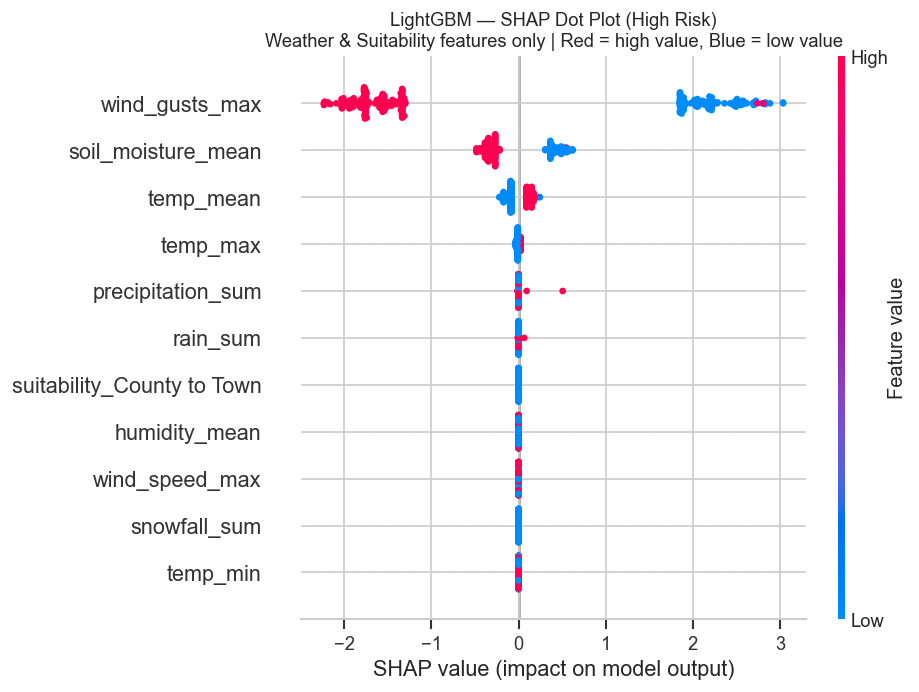

In [52]:
# ── SHAP Summary Dot Plot — distribution of SHAP values across all samples ──
# Keep only weather + suitability features (exclude town_*, latitude, longitude)
GEO_EXCLUDE = {'latitude', 'longitude'}
weather_suit_cols = [
    c for c in X_sample.columns
    if not c.startswith('town_') and c not in GEO_EXCLUDE
]
X_sample_ws = X_sample[weather_suit_cols]
sv_ws = sv[:, [list(X_sample.columns).index(c) for c in weather_suit_cols]]

shap.summary_plot(sv_ws, X_sample_ws,
                  feature_names=weather_suit_cols,
                  max_display=15, show=False)
plt.title(f'{best_name} — SHAP Dot Plot (High Risk)\n'
          f'Weather & Suitability features only | Red = high value, Blue = low value',
          fontsize=11)
plt.tight_layout(); plt.savefig('shap_dot_plot.png', bbox_inches='tight'); plt.show()


---
## Step 15 — Export Model & JSON Files for Web App

Run this step once after training. It saves everything the Flask API needs:
- `flood_model.pkl` — the trained model
- `feature_order.json` — exact column order the model expects
- `model_metadata.json` — model info (accuracy, classes, towns, suitability types)
- `risk_mapping.json` — maps numeric prediction → label

In [53]:
import joblib, json, os

# ── Save model ──────────────────────────────────────────────────────────────────
joblib.dump(best_model, 'flood_model.pkl')
print(f"✅ flood_model.pkl  ({os.path.getsize('flood_model.pkl')/1024:.1f} KB)")

# ── risk_mapping.json ───────────────────────────────────────────────────────────
risk_map = {str(v): k for k, v in RISK_MAPPING.items()}
with open('risk_mapping.json', 'w') as f:
    json.dump(risk_map, f, indent=2)
print(f"✅ risk_mapping.json  →  {risk_map}")

# ── feature_order.json ──────────────────────────────────────────────────────────
with open('feature_order.json', 'w') as f:
    json.dump(feature_cols, f, indent=2)
print(f"✅ feature_order.json  ({len(feature_cols)} features)")

# ── Extract towns and suitability types from OHE columns ───────────────────────
towns_in_model = sorted([c.replace('town_', '') for c in feature_cols if c.startswith('town_')])
suit_in_model  = sorted([c.replace('suitability_', '') for c in feature_cols if c.startswith('suitability_')])

# ── model_metadata.json ─────────────────────────────────────────────────────────
meta = {
    'model_name':        best_name,
    'model_class':       type(best_model).__name__,
    'classes':           risk_map,
    'test_accuracy':     round(float(best['test_acc']), 4),
    'test_f1_weighted':  round(float(best['f1']), 4),
    'train_test_gap':    round(float(best['gap']), 4),
    'n_features':        len(feature_cols),
    'feature_cols':      feature_cols,
    'towns':             towns_in_model,
    'suitability_types': suit_in_model,
    'target_order':      TARGET_ORDER,
    'training_region':   'North East & Yorkshire, UK',
}
with open('model_metadata.json', 'w') as f:
    json.dump(meta, f, indent=2)
print(f"✅ model_metadata.json")
print(f"\n   Towns in model      : {towns_in_model}")
print(f"   Suitability types   : {suit_in_model}")
print(f"   Best model          : {best_name}")
print(f"   Test F1             : {best['f1']:.4f}")
print(f"\n✅ All export files ready — copy these 4 files into your web app folder.")

✅ flood_model.pkl  (1635.7 KB)
✅ risk_mapping.json  →  {'0': 'Low', '1': 'Medium', '2': 'High'}
✅ feature_order.json  (18 features)
✅ model_metadata.json

   Towns in model      : ['Bradford', 'Doncaster', 'Leeds', 'Newcastle upon Tyne', 'Sheffield']
   Suitability types   : ['County to Town']
   Best model          : LightGBM
   Test F1             : 0.8366

✅ All export files ready — copy these 4 files into your web app folder.
